## 1. Environment Setup and Reproducible Output Paths


In [1]:
from pathlib import Path

IN_COLAB = False
print("Using local project storage; Google Drive is disabled for this notebook.")


Using local project storage; Google Drive is disabled for this notebook.


In [2]:
import os
from pathlib import Path

project_root = Path.cwd()
base_path = project_root / "dissertation_outputs"

mpl_config_dir = project_root / ".mplconfig"
mpl_config_dir.mkdir(parents=True, exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(mpl_config_dir)

folders = ["data", "models", "figures", "results"]
for folder in folders:
    (base_path / folder).mkdir(parents=True, exist_ok=True)

print(f"Base path: {base_path}")
print(f"MPLCONFIGDIR: {mpl_config_dir}")


Base path: c:\Code\dissertation_outputs
MPLCONFIGDIR: c:\Code\.mplconfig


## 2. Install and Import Libraries


In [3]:
!pip install -q yfinance shap seaborn joblib


In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    jaccard_score,
    precision_recall_fscore_support
)
from scipy.stats import ttest_ind, wilcoxon, spearmanr
from sklearn.svm import OneClassSVM

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)

plt.style.use("default")
sns.set_theme(style="whitegrid")


c:\Code\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


##3. Data Collection
####3.1 Download Financial Data

In [5]:
tickers = ["AAPL", "MSFT", "NVDA", "AMZN", "JPM", "GS", "KO", "XOM", "SPY", "QQQ"]

# Download a broader multi-asset dataset for a stronger dissertation-grade study
data = yf.download(
    tickers,
    start="2010-01-01",
    end="2024-01-01",
    auto_adjust=False,
    group_by="column"
)

print(data.shape)
data.head()

[*********************100%***********************]  10 of 10 completed

(3522, 60)


Price      Adj Close                                                       \
Ticker          AAPL    AMZN          GS        JPM         KO       MSFT   
Date                                                                        
2010-01-04  6.412384  6.6950  129.957626  28.279203  17.316330  23.077383   
2010-01-05  6.423470  6.7345  132.255203  28.826967  17.106859  23.084837   
2010-01-06  6.321296  6.6125  130.843628  28.985350  17.100788  22.943172   
2010-01-07  6.309611  6.5000  133.404083  29.559536  17.058281  22.704552   
2010-01-08  6.351557  6.6760  130.881210  29.486917  16.742565  22.861147   

Price                                                  ...     Volume  \
Ticker          NVDA        QQQ        SPY        XOM  ...       AAPL   
Date                                                   ...              
2010-01-04  0.423784  40.290775  84.796387  37.630985  ...  493729600   
2010-01-05  0.429972  40.290775  85.020836  37.777912  ...  601904800   
2010-01-06  0.432722  40.047749  85.080719  38.104427  ...  552160000   
2010-01-07  0.424242  40.073803  85.439835  37.984703  ...  477131200   
2010-01-08  0.425159  40.403614  85.724174  37.832306  ...  447610800   

Price                                                                     \
Ticker           AMZN        GS       JPM        KO      MSFT       NVDA   
Date                                                                       
2010-01-04  151998000   9135000  35460500  13870400  38409100  800204000   
2010-01-05  177038000  11659400  41208300  23172400  49749600  728648000   
2010-01-06  143576000   7381100  27729000  19264600  58182400  649168000   
2010-01-07  220604000   8727400  44864700  13234600  50559700  547792000   
2010-01-08  196610000   7268100  33110100  28712400  51197400  478168000   

Price                                      
Ticker           QQQ        SPY       XOM  
Date                                       
2010-01-04  62822800  118944600  27809100  
2010-01-05  62935600  111579900  30174700  
2010-01-06  96033000  116074400  35044700  
2010-01-07  77094100  131091100  27192100  
2010-01-08  88886600  126402800  24891800  

[5 rows x 60 columns]

#### 3.2 Save Raw Data

In [6]:
raw_data_path = os.path.join(base_path, "data", "market_data_raw.csv")
data.to_csv(raw_data_path)
print(f"Raw data saved to: {raw_data_path}")

Raw data saved to: c:\Code\dissertation_outputs\data\market_data_raw.csv


## 4. Exploratory Data Analysis
####4.1 Closing Prices

In [7]:
# Extract closing prices from the wide-format market dataset
close_prices = data["Close"].copy()
close_prices.head()

Ticker,AAPL,AMZN,GS,JPM,KO,MSFT,NVDA,QQQ,SPY,XOM
Date,,,,,,,,,,
2010-01-04,7.643214,6.6950,173.080002,42.849998,28.520000,30.950001,0.46225,46.419998,113.330002,69.150002
2010-01-05,7.656429,6.7345,176.139999,43.680000,28.174999,30.959999,0.46900,46.419998,113.629997,69.419998
2010-01-06,7.534643,6.6125,174.259995,43.919998,28.165001,30.770000,0.47200,46.139999,113.709999,70.019997
2010-01-07,7.520714,6.5000,177.669998,44.790001,28.094999,30.450001,0.46275,46.169998,114.190002,69.800003
2010-01-08,7.570714,6.6760,174.309998,44.680000,27.575001,30.660000,0.46375,46.549999,114.570000,69.519997


####4.2 Plot Stock Price trends

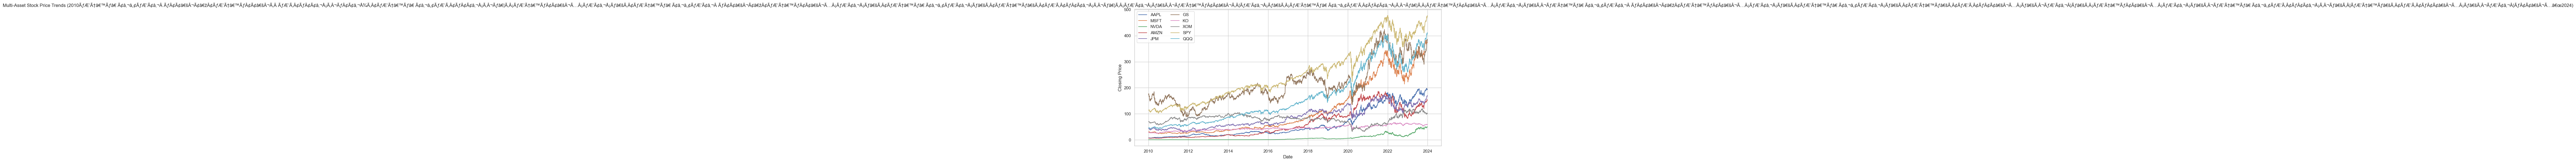

Figure saved to: c:\Code\dissertation_outputs\figures\stock_price_trends_multi_asset.png


In [8]:
plt.figure(figsize=(12,6))

for ticker in tickers:
    if ticker in close_prices.columns:
        plt.plot(close_prices.index, close_prices[ticker], label=ticker)

plt.title("Multi-Asset Stock Price Trends (2010ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â¦ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Â¦ÃƒÂ¢Ã¢â€šÂ¬Ã…â€œ2024)")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend(ncol=2)
plt.tight_layout()

fig_path = os.path.join(base_path, "figures", "stock_price_trends_multi_asset.png")
plt.savefig(fig_path, dpi=300)
plt.show()

print(f"Figure saved to: {fig_path}")

#### 4.3 Daily Returns

In [9]:
returns_all = close_prices.pct_change()
print(returns_all.shape)
returns_all.head()

(3522, 10)


Ticker,AAPL,AMZN,GS,JPM,KO,MSFT,NVDA,QQQ,SPY,XOM
Date,,,,,,,,,,
2010-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-05,0.001729,0.005900,0.017680,0.019370,-0.012097,0.000323,0.014603,0.000000,0.002647,0.003905
2010-01-06,-0.015906,-0.018116,-0.010673,0.005494,-0.000355,-0.006137,0.006397,-0.006032,0.000704,0.008643
2010-01-07,-0.001849,-0.017013,0.019568,0.019809,-0.002485,-0.010400,-0.019597,0.000650,0.004221,-0.003142
2010-01-08,0.006648,0.027077,-0.018911,-0.002456,-0.018509,0.006897,0.002161,0.008230,0.003328,-0.004012


####4.4 Returns Distribution for AAPL

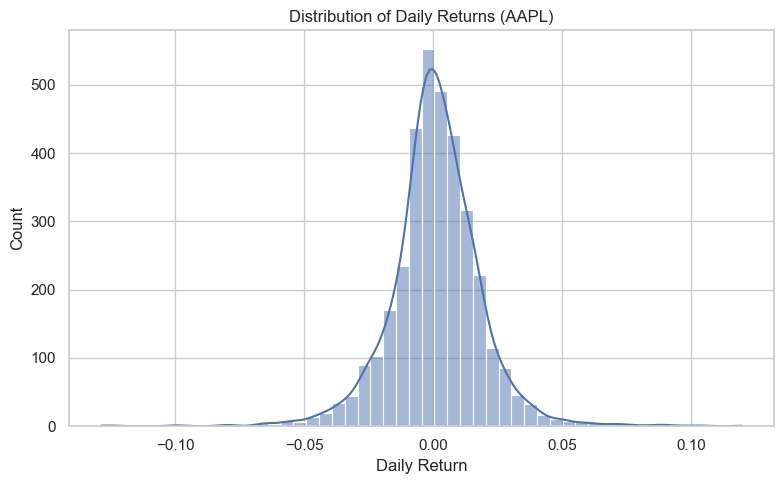

Figure saved to: c:\Code\dissertation_outputs\figures\aapl_returns_distribution.png


In [10]:
plt.figure(figsize=(8,5))
sns.histplot(returns_all["AAPL"].dropna(), bins=50, kde=True)
plt.title("Distribution of Daily Returns (AAPL)")
plt.xlabel("Daily Return")
plt.tight_layout()

fig_path = os.path.join(base_path, "figures", "aapl_returns_distribution.png")
plt.savefig(fig_path,dpi=300)
plt.show()

print(f"Figure saved to: {fig_path}")

#### 4.5 Correlation Heatmap

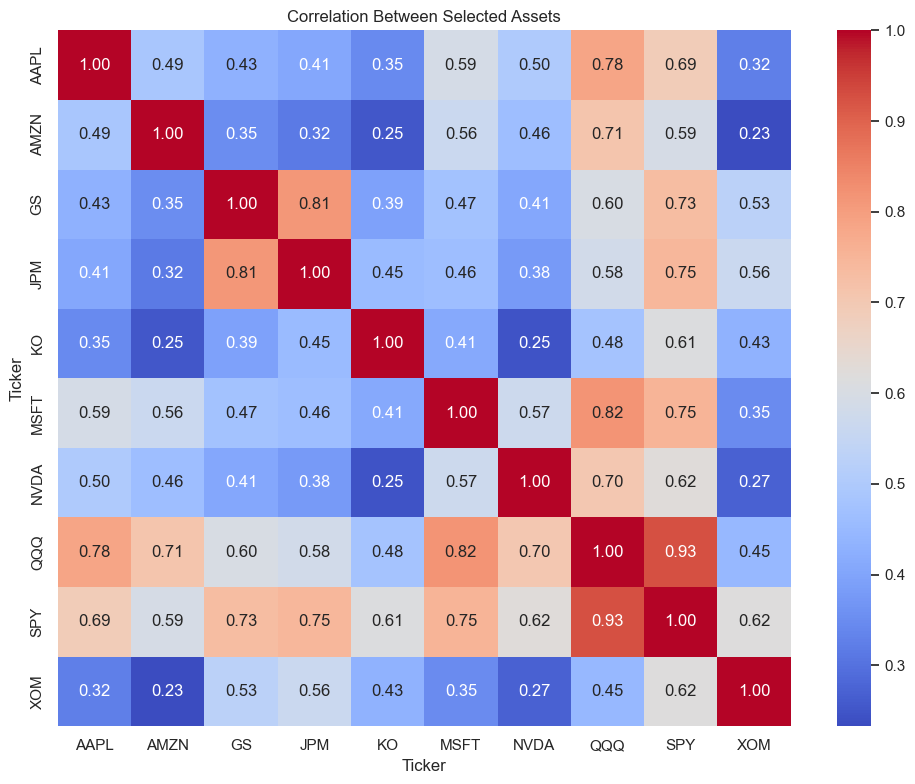

Figure saved to: c:\Code\dissertation_outputs\figures\asset_correlation_heatmap.png


In [11]:
corr = returns_all

plt.figure(figsize=(10,8))
sns.heatmap(corr.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Selected Assets")
plt.tight_layout()

fig_path = os.path.join(base_path, "figures", "asset_correlation_heatmap.png")
plt.savefig(fig_path,dpi=300)
plt.show()

print(f"Figure saved to: {fig_path}")

## 5. Feature Engineering

we will build the main modeling dataset using AAPL as the base asset for anomaly detection.



#### 5.1 Create Financial Features

In [12]:
# Convert the wide-format dataset into long format so that features can be built per asset

data_long = data.stack(level=1).reset_index()
data_long.columns = ["Date", "Ticker", "Adj Close", "Close", "High", "Low", "Open", "Volume"]
data_long = data_long[["Date", "Ticker", "Open", "High", "Low", "Close", "Adj Close", "Volume"]]
data_long = data_long.sort_values(["Ticker", "Date"]).reset_index(drop=True)

# Feature engineering for each ticker separately
data_long["Return"] = data_long.groupby("Ticker")["Close"].pct_change()
data_long["Volatility_10"] = data_long.groupby("Ticker")["Return"].rolling(window=10).std().reset_index(level=0, drop=True)
data_long["Volatility_20"] = data_long.groupby("Ticker")["Return"].rolling(window=20).std().reset_index(level=0, drop=True)
data_long["MA_10"] = data_long.groupby("Ticker")["Close"].rolling(window=10).mean().reset_index(level=0, drop=True)
data_long["MA_20"] = data_long.groupby("Ticker")["Close"].rolling(window=20).mean().reset_index(level=0, drop=True)
data_long["Momentum_10"] = data_long.groupby("Ticker")["Close"].diff(10)
data_long["MA_Ratio_10"] = data_long["Close"] / data_long["MA_10"]
data_long["MA_Ratio_20"] = data_long["Close"] / data_long["MA_20"]
data_long["Volume_Change"] = data_long.groupby("Ticker")["Volume"].pct_change()

# Additional dissertation-level technical indicators
data_long["Rolling_Skew_20"] = data_long.groupby("Ticker")["Return"].rolling(window=20).skew().reset_index(level=0, drop=True)
data_long["Rolling_Kurt_20"] = data_long.groupby("Ticker")["Return"].rolling(window=20).kurt().reset_index(level=0, drop=True)
data_long["Return_Zscore_20"] = data_long.groupby("Ticker")["Return"].transform(lambda x: (x - x.rolling(20).mean()) / x.rolling(20).std())
data_long["Drawdown"] = data_long.groupby("Ticker")["Close"].transform(lambda x: x / x.cummax() - 1)

# RSI(14)
def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(period).mean()
    avg_loss = loss.rolling(period).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

data_long["RSI_14"] = data_long.groupby("Ticker")["Close"].transform(lambda x: compute_rsi(x, 14))

# MACD and signal line
ema12 = data_long.groupby("Ticker")["Close"].transform(lambda x: x.ewm(span=12, adjust=False).mean())
ema26 = data_long.groupby("Ticker")["Close"].transform(lambda x: x.ewm(span=26, adjust=False).mean())
data_long["MACD"] = ema12 - ema26
data_long["MACD_Signal"] = data_long.groupby("Ticker")["MACD"].transform(lambda x: x.ewm(span=9, adjust=False).mean())

# Bollinger Band width (20-day)
rolling_mean_20 = data_long.groupby("Ticker")["Close"].transform(lambda x: x.rolling(20).mean())
rolling_std_20 = data_long.groupby("Ticker")["Close"].transform(lambda x: x.rolling(20).std())
upper_band = rolling_mean_20 + 2 * rolling_std_20
lower_band = rolling_mean_20 - 2 * rolling_std_20
data_long["BB_Width"] = (upper_band - lower_band) / rolling_mean_20

data_long.dropna(inplace=True)
data_long.reset_index(drop=True, inplace=True)

# Keep df as the main modelling table for downstream compatibility
df = data_long.copy()
print(df.shape)
df.head()

(35020, 25)


,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,Return,Volatility_10,...,MA_Ratio_20,Volume_Change,Rolling_Skew_20,Rolling_Kurt_20,Return_Zscore_20,Drawdown,RSI_14,MACD,MACD_Signal,BB_Width
0,2010-02-02,AAPL,6.996786,7.011429,6.906429,6.995000,5.868555,698342400,0.005803,0.026778,...,0.950046,-0.068723,-0.094722,0.228657,0.437231,-0.089193,40.705333,-0.153625,-0.104272,0.131490
1,2010-02-03,AAPL,6.970357,7.150000,6.943571,7.115357,5.969530,615328000,0.017206,0.027872,...,0.969956,-0.118873,-0.155633,0.002006,0.884956,-0.073521,41.111458,-0.149129,-0.113243,0.129604
2,2010-02-04,AAPL,7.026071,7.084643,6.841786,6.858929,5.754396,757652000,-0.036039,0.029330,...,0.939327,0.231298,-0.133404,-0.348351,-1.303548,-0.106910,37.621088,-0.164363,-0.123467,0.139852
3,2010-02-05,AAPL,6.879643,7.000000,6.816071,6.980714,5.856568,850306800,0.017756,0.026174,...,0.959553,0.122292,-0.215662,-0.522514,0.855214,-0.091053,42.533146,-0.164710,-0.131716,0.142663
4,2010-02-08,AAPL,6.988929,7.067143,6.928571,6.932857,5.816419,478270800,-0.006856,0.024307,...,0.957171,-0.437531,-0.131291,-0.496614,-0.111724,-0.097284,33.221029,-0.166922,-0.138757,0.143807


#### 5.2 Save Feature Dataset

In [13]:
feature_data_path = os.path.join(base_path, "data", "multi_asset_financial_features.csv")
df.to_csv(feature_data_path, index=False)
print(f"Feature data saved to: {feature_data_path}")

Feature data saved to: c:\Code\dissertation_outputs\data\multi_asset_financial_features.csv


#### 5.3 Feature Correlation Heatmap

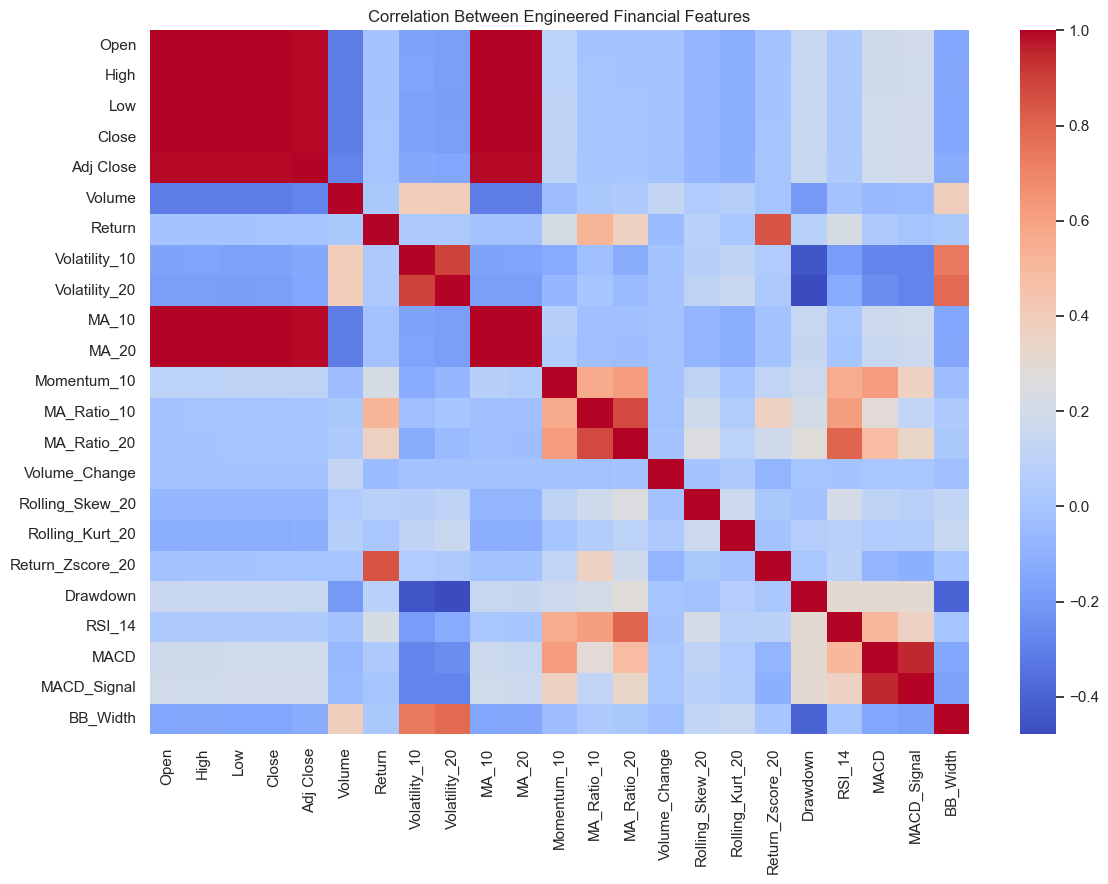

Figure saved to: c:\Code\dissertation_outputs\figures\feature_correlation_heatmap_multi_asset.png


In [14]:
numeric_corr = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(12,9))
sns.heatmap(numeric_corr, annot=False, cmap="coolwarm")
plt.title("Correlation Between Engineered Financial Features")
plt.tight_layout()

fig_path = os.path.join(base_path, "figures", "feature_correlation_heatmap_multi_asset.png")
plt.savefig(fig_path, dpi=300)
plt.show()

print(f"Figure saved to: {fig_path}")

#### 5.4 Rolling Volatility Plot

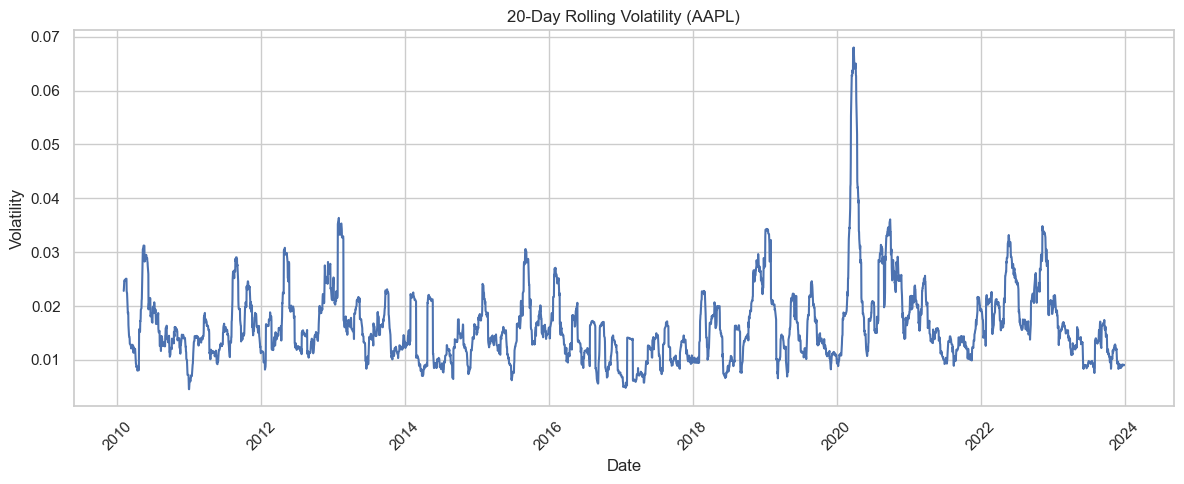

Figure saved to: c:\Code\dissertation_outputs\figures\rolling_volatility_plot_aapl.png


In [15]:
plot_vol_df = df[df["Ticker"] == "AAPL"].copy()
plt.figure(figsize=(12,5))
plt.plot(plot_vol_df["Date"], plot_vol_df["Volatility_20"])
plt.title("20-Day Rolling Volatility (AAPL)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.xticks(rotation=45)
plt.tight_layout()

fig_path = os.path.join(base_path, "figures", "rolling_volatility_plot_aapl.png")
plt.savefig(fig_path, dpi=300)
plt.show()

print(f"Figure saved to: {fig_path}")

## 6. Prepare Model Features

In [16]:
feature_cols = [
    "Return",
    "Volatility_10",
    "Volatility_20",
    "Momentum_10",
    "MA_Ratio_10",
    "MA_Ratio_20",
    "Volume_Change",
    "Rolling_Skew_20",
    "Rolling_Kurt_20",
    "Return_Zscore_20",
    "Drawdown",
    "RSI_14",
    "MACD",
    "MACD_Signal",
    "BB_Width"
]

X = df[feature_cols].copy()
print(X.shape)
X.head()

(35020, 15)


,Return,Volatility_10,Volatility_20,Momentum_10,MA_Ratio_10,MA_Ratio_20,Volume_Change,Rolling_Skew_20,Rolling_Kurt_20,Return_Zscore_20,Drawdown,RSI_14,MACD,MACD_Signal,BB_Width
0,0.005803,0.026778,0.022815,-0.685000,0.971345,0.950046,-0.068723,-0.094722,0.228657,0.437231,-0.089193,40.705333,-0.153625,-0.104272,0.131490
1,0.017206,0.027872,0.023283,-0.446429,0.994221,0.969956,-0.118873,-0.155633,0.002006,0.884956,-0.073521,41.111458,-0.149129,-0.113243,0.129604
2,-0.036039,0.029330,0.024267,-0.572142,0.966114,0.939327,0.231298,-0.133404,-0.348351,-1.303548,-0.106910,37.621088,-0.164363,-0.123467,0.139852
3,0.017756,0.026174,0.024767,-0.081786,0.984402,0.959553,0.122292,-0.215662,-0.522514,0.855214,-0.091053,42.533146,-0.164710,-0.131716,0.142663
4,-0.006856,0.024307,0.024661,-0.319643,0.982081,0.957171,-0.437531,-0.131291,-0.496614,-0.111724,-0.097284,33.221029,-0.166922,-0.138757,0.143807


In [17]:
model_features_path = os.path.join(base_path, "data", "multi_asset_model_features.csv")
X.to_csv(model_features_path, index=False)
print(f"Model features saved to: {model_features_path}")

Model features saved to: c:\Code\dissertation_outputs\data\multi_asset_model_features.csv


## 7. Time-Series Evaluation Design


In [18]:
df = df.sort_values(["Date", "Ticker"]).reset_index(drop=True)
df["Date"] = pd.to_datetime(df["Date"])

unique_dates = np.array(sorted(df["Date"].dt.normalize().unique()))
train_end = int(len(unique_dates) * 0.70)
val_end = int(len(unique_dates) * 0.85)

train_dates = set(unique_dates[:train_end])
val_dates = set(unique_dates[train_end:val_end])

def assign_split(date_value):
    normalized = pd.Timestamp(date_value).normalize().to_datetime64()
    if normalized in train_dates:
        return "Train"
    if normalized in val_dates:
        return "Validation"
    return "Test"

df["Split"] = df["Date"].apply(assign_split)

eval_df = df.copy()
eval_df["Evaluation_Label"] = 0
eval_df["Evaluation_Event_ID"] = ""
eval_df["Evaluation_Scenario"] = "Baseline"

def inject_event_block(frame, row_index, scenario_name, event_id, severity):
    frame.loc[row_index, "Evaluation_Label"] = 1
    frame.loc[row_index, "Evaluation_Event_ID"] = event_id
    frame.loc[row_index, "Evaluation_Scenario"] = scenario_name

    if scenario_name == "Price Spike":
        frame.loc[row_index, "Return"] = frame.loc[row_index, "Return"] * (1.0 + 1.20 * severity)
        frame.loc[row_index, "Momentum_10"] = frame.loc[row_index, "Momentum_10"] * (1.0 + 0.80 * severity)
        frame.loc[row_index, "MA_Ratio_10"] = frame.loc[row_index, "MA_Ratio_10"] * (1.0 + 0.10 * severity)
        frame.loc[row_index, "MA_Ratio_20"] = frame.loc[row_index, "MA_Ratio_20"] * (1.0 + 0.12 * severity)
        frame.loc[row_index, "Return_Zscore_20"] = frame.loc[row_index, "Return_Zscore_20"] + (2.0 * severity)
        frame.loc[row_index, "RSI_14"] = np.clip(frame.loc[row_index, "RSI_14"] + (18 * severity), 0, 100)
    elif scenario_name == "Volume Shock":
        frame.loc[row_index, "Volume_Change"] = frame.loc[row_index, "Volume_Change"].fillna(0) + (2.5 * severity)
        frame.loc[row_index, "Volatility_10"] = frame.loc[row_index, "Volatility_10"] * (1.0 + 0.70 * severity)
        frame.loc[row_index, "Volatility_20"] = frame.loc[row_index, "Volatility_20"] * (1.0 + 0.60 * severity)
        frame.loc[row_index, "BB_Width"] = frame.loc[row_index, "BB_Width"] * (1.0 + 0.90 * severity)
        frame.loc[row_index, "Rolling_Skew_20"] = frame.loc[row_index, "Rolling_Skew_20"] + (0.60 * severity)
    elif scenario_name == "Volatility Shock":
        frame.loc[row_index, "Volatility_10"] = frame.loc[row_index, "Volatility_10"] * (1.0 + 1.20 * severity)
        frame.loc[row_index, "Volatility_20"] = frame.loc[row_index, "Volatility_20"] * (1.0 + 1.30 * severity)
        frame.loc[row_index, "Return_Zscore_20"] = frame.loc[row_index, "Return_Zscore_20"] + (3.0 * severity)
        frame.loc[row_index, "Drawdown"] = frame.loc[row_index, "Drawdown"] - (0.12 * severity)
        frame.loc[row_index, "BB_Width"] = frame.loc[row_index, "BB_Width"] * (1.0 + 1.10 * severity)
        frame.loc[row_index, "Rolling_Kurt_20"] = frame.loc[row_index, "Rolling_Kurt_20"] + (1.40 * severity)

event_log = []
scenario_cycle = ["Price Spike", "Volume Shock", "Volatility Shock"]

for split_name, severity, stride in [("Validation", 1.0, 120), ("Test", 1.2, 90)]:
    for ticker in tickers:
        ticker_index = eval_df.index[(eval_df["Split"] == split_name) & (eval_df["Ticker"] == ticker)].tolist()
        if len(ticker_index) < 40:
            continue
        positions = list(range(20, len(ticker_index) - 3, stride))[:3]
        for event_num, pos in enumerate(positions, start=1):
            row_index = ticker_index[pos:pos + 3]
            scenario_name = scenario_cycle[(event_num - 1) % len(scenario_cycle)]
            event_id = f"{split_name}_{ticker}_{event_num}"
            inject_event_block(eval_df, row_index, scenario_name, event_id, severity)
            event_log.append({
                "Event_ID": event_id,
                "Split": split_name,
                "Ticker": ticker,
                "Scenario": scenario_name,
                "Start_Date": eval_df.loc[row_index[0], "Date"],
                "End_Date": eval_df.loc[row_index[-1], "Date"],
                "Injected_Rows": len(row_index)
            })

event_log_df = pd.DataFrame(event_log)
split_summary_df = df.groupby("Split").agg(Rows=("Ticker", "size"), Assets=("Ticker", "nunique"), Start_Date=("Date", "min"), End_Date=("Date", "max")).reset_index()
print(split_summary_df)
print(eval_df["Evaluation_Label"].value_counts())
event_log_df.head()


        Split   Rows  Assets Start_Date   End_Date
0        Test   5260      10 2021-11-26 2023-12-29
1       Train  24510      10 2010-02-02 2019-10-25
2  Validation   5250      10 2019-10-28 2021-11-24
Evaluation_Label
0    34840
1      180
Name: count, dtype: int64


,Event_ID,Split,Ticker,Scenario,Start_Date,End_Date,Injected_Rows
0,Validation_AAPL_1,Validation,AAPL,Price Spike,2019-11-25,2019-11-27,3
1,Validation_AAPL_2,Validation,AAPL,Volume Shock,2020-05-19,2020-05-21,3
2,Validation_AAPL_3,Validation,AAPL,Volatility Shock,2020-11-06,2020-11-10,3
3,Validation_MSFT_1,Validation,MSFT,Price Spike,2019-11-25,2019-11-27,3
4,Validation_MSFT_2,Validation,MSFT,Volume Shock,2020-05-19,2020-05-21,3


#### 7.1 Save Chronological Split Metadata and Controlled Evaluation Labels


In [19]:
evaluation_dataset_path = base_path / "data" / "evaluation_dataset_with_injected_events.csv"
event_log_path = base_path / "data" / "synthetic_event_log.csv"
split_summary_path = base_path / "results" / "time_series_split_summary.csv"

eval_df.to_csv(evaluation_dataset_path, index=False)
event_log_df.to_csv(event_log_path, index=False)
split_summary_df.to_csv(split_summary_path, index=False)

print(f"Evaluation dataset saved to: {evaluation_dataset_path}")
print(f"Event log saved to: {event_log_path}")
print(f"Split summary saved to: {split_summary_path}")


Evaluation dataset saved to: c:\Code\dissertation_outputs\data\evaluation_dataset_with_injected_events.csv
Event log saved to: c:\Code\dissertation_outputs\data\synthetic_event_log.csv
Split summary saved to: c:\Code\dissertation_outputs\results\time_series_split_summary.csv


## 8. Isolation Forest Model


#### 8.1 Train on the Chronological Training Split Only


In [20]:
split_feature_frames = {split_name: df.loc[df["Split"] == split_name, feature_cols].copy() for split_name in ["Train", "Validation", "Test"]}

X_train = split_feature_frames["Train"].copy()
X_val = split_feature_frames["Validation"].copy()
X_test = split_feature_frames["Test"].copy()

iso_model = IsolationForest(n_estimators=200, contamination=0.01, random_state=42)
iso_model.fit(X_train)

df["IF_raw"] = np.nan
df["Anomaly_IF"] = 0
df["IF_score"] = np.nan

for split_name, split_frame in split_feature_frames.items():
    split_mask = df["Split"] == split_name
    raw_pred = iso_model.predict(split_frame)
    score_pred = iso_model.decision_function(split_frame)
    df.loc[split_mask, "IF_raw"] = raw_pred
    df.loc[split_mask, "Anomaly_IF"] = pd.Series(raw_pred, index=split_frame.index).replace({1: 0, -1: 1}).astype(int)
    df.loc[split_mask, "IF_score"] = score_pred

if_split_counts = df.groupby("Split")["Anomaly_IF"].agg(["sum", "mean"]).rename(columns={"sum": "Anomalies", "mean": "Anomaly_Rate"}).reset_index()
if_split_counts


,Split,Anomalies,Anomaly_Rate
0,Test,158,0.030038
1,Train,246,0.010037
2,Validation,281,0.053524


#### 8.2 Save Isolation Forest Model


In [21]:
iso_model_path = base_path / "models" / "isolation_forest_train_only.pkl"
joblib.dump(iso_model, iso_model_path)
print(f"Isolation Forest model saved to: {iso_model_path}")


Isolation Forest model saved to: c:\Code\dissertation_outputs\models\isolation_forest_train_only.pkl


#### 8.3 Isolation Forest Held-Out Anomalies on the Test Split


        Split  Anomalies  Anomaly_Rate
0        Test        158      0.030038
1       Train        246      0.010037
2  Validation        281      0.053524


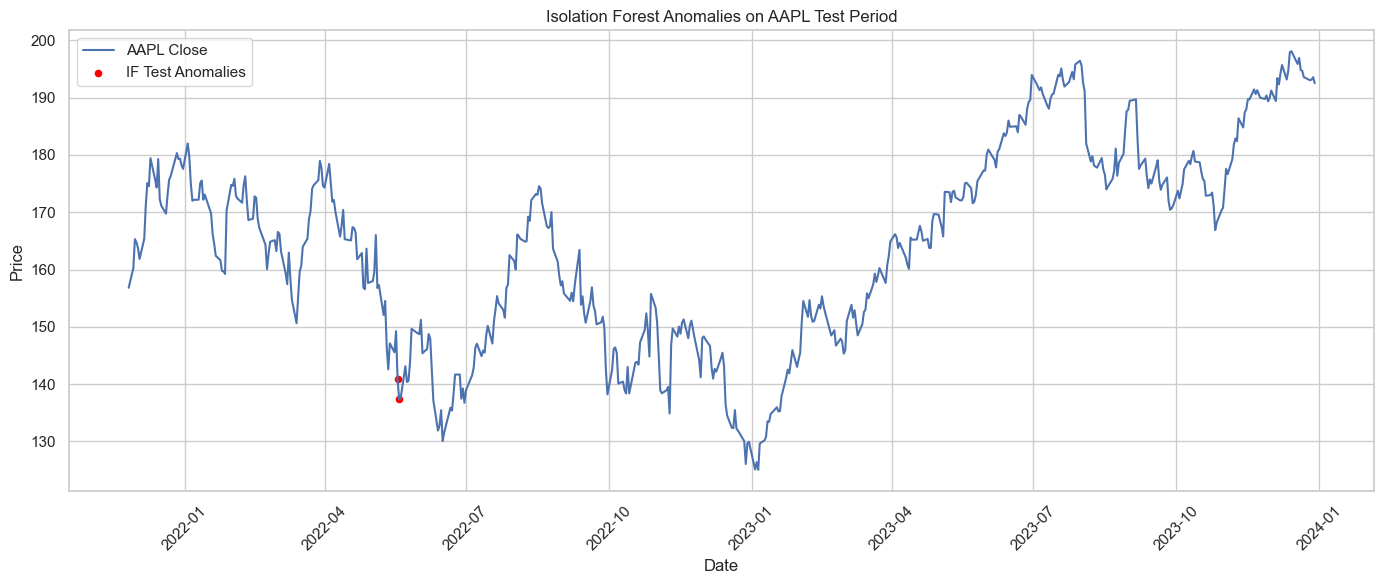

Figure saved to: c:\Code\dissertation_outputs\figures\if_test_period_anomalies_aapl.png


In [22]:
print(if_split_counts)

plot_df = df[(df["Ticker"] == "AAPL") & (df["Split"] == "Test")].copy()

plt.figure(figsize=(14, 6))
plt.plot(plot_df["Date"], plot_df["Close"], label="AAPL Close")
plt.scatter(
    plot_df.loc[plot_df["Anomaly_IF"] == 1, "Date"],
    plot_df.loc[plot_df["Anomaly_IF"] == 1, "Close"],
    color="red",
    s=20,
    label="IF Test Anomalies"
)
plt.title("Isolation Forest Anomalies on AAPL Test Period")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

fig_path = base_path / "figures" / "if_test_period_anomalies_aapl.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print(f"Figure saved to: {fig_path}")


## 9. Autoencoder Model


#### 9.1 Fit the Feature Scaler on the Training Split Only


In [23]:
scaler = StandardScaler()
X_scaled_train = scaler.fit_transform(X_train)
X_scaled_by_split = {split_name: scaler.transform(split_frame) for split_name, split_frame in split_feature_frames.items()}

scaler_path = base_path / "models" / "standard_scaler_train_only.pkl"
joblib.dump(scaler, scaler_path)
print(f"Scaler saved to: {scaler_path}")


Scaler saved to: c:\Code\dissertation_outputs\models\standard_scaler_train_only.pkl


#### 9.2 Build Autoencoder Architecture


In [24]:
input_dim = X_scaled_train.shape[1]

input_layer = Input(shape=(input_dim,))
encoded = Dense(32, activation="relu")(input_layer)
encoded = Dense(16, activation="relu")(encoded)
encoded = Dense(8, activation="relu")(encoded)
decoded = Dense(16, activation="relu")(encoded)
decoded = Dense(32, activation="relu")(decoded)
decoded = Dense(input_dim, activation="linear")(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss="mse")
autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 15)             │           495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,359 (9.21 KB)

 Trainable params: 2,359 (9.21 KB)

 Non-trainable params: 0 (0.00 B)

#### 9.3 Train Autoencoder on Training Data Only


In [25]:
history = autoencoder.fit(
    X_scaled_train,
    X_scaled_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)


Epoch 1/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5176 - val_loss: 0.3593
Epoch 2/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2151 - val_loss: 0.2088
Epoch 3/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1428 - val_loss: 0.1652
Epoch 4/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1115 - val_loss: 0.1309
Epoch 5/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0802 - val_loss: 0.1145
Epoch 6/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0712 - val_loss: 0.1073
Epoch 7/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0666 - val_loss: 0.1021
Epoch 8/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0636 - val_loss: 0.0987
Epoch 9/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0612 - val_loss: 0.0959
Epoch 10/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0593 - val_loss: 0.0934
Epoch 11/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0577 - val_loss: 0.0913
Epoch 12/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

#### 9.4 Save Autoencoder Model


In [26]:
ae_model_path = base_path / "models" / "multi_asset_autoencoder_train_only.h5"
autoencoder.save(ae_model_path)
print(f"Autoencoder model saved to: {ae_model_path}")


Autoencoder model saved to: c:\Code\dissertation_outputs\models\multi_asset_autoencoder_train_only.h5


#### 9.5 Autoencoder Reconstruction Errors and Baseline Labels


In [27]:
train_reconstructions = autoencoder.predict(X_scaled_train, verbose=0)
train_mse = np.mean(np.square(X_scaled_train - train_reconstructions), axis=1)
ae_threshold = np.quantile(train_mse, 0.99)

df["AE_error"] = np.nan
df["Anomaly_AE"] = 0

for split_name, split_scaled in X_scaled_by_split.items():
    split_mask = df["Split"] == split_name
    reconstructions = autoencoder.predict(split_scaled, verbose=0)
    mse = np.mean(np.square(split_scaled - reconstructions), axis=1)
    df.loc[split_mask, "AE_error"] = mse
    df.loc[split_mask, "Anomaly_AE"] = (mse > ae_threshold).astype(int)

ae_split_counts = df.groupby("Split")["Anomaly_AE"].agg(["sum", "mean"]).rename(columns={"sum": "Anomalies", "mean": "Anomaly_Rate"}).reset_index()
print(f"Autoencoder threshold (99th percentile of train error): {ae_threshold:.6f}")
ae_split_counts


Autoencoder threshold (99th percentile of train error): 0.288518


,Split,Anomalies,Anomaly_Rate
0,Test,775,0.147338
1,Train,246,0.010037
2,Validation,491,0.093524


#### 9.6 Autoencoder Held-Out Results


In [28]:
print(ae_split_counts)


        Split  Anomalies  Anomaly_Rate
0        Test        775      0.147338
1       Train        246      0.010037
2  Validation        491      0.093524


## 10. One-Class SVM Baseline and Shared Visual Diagnostics


In [29]:
ocsvm_model = OneClassSVM(kernel="rbf", nu=0.01, gamma="scale")
ocsvm_model.fit(X_scaled_train)

df["OCSVM_raw"] = np.nan
df["Anomaly_OCSVM"] = 0
df["OCSVM_score"] = np.nan

for split_name, split_scaled in X_scaled_by_split.items():
    split_mask = df["Split"] == split_name
    raw_pred = ocsvm_model.predict(split_scaled)
    score_pred = ocsvm_model.decision_function(split_scaled)
    df.loc[split_mask, "OCSVM_raw"] = raw_pred
    df.loc[split_mask, "Anomaly_OCSVM"] = pd.Series(raw_pred, index=split_feature_frames[split_name].index).replace({1: 0, -1: 1}).astype(int)
    df.loc[split_mask, "OCSVM_score"] = score_pred

ocsvm_model_path = base_path / "models" / "one_class_svm_train_only.pkl"
joblib.dump(ocsvm_model, ocsvm_model_path)
ocsvm_split_counts = df.groupby("Split")["Anomaly_OCSVM"].agg(["sum", "mean"]).rename(columns={"sum": "Anomalies", "mean": "Anomaly_Rate"}).reset_index()
print(f"One-Class SVM model saved to: {ocsvm_model_path}")
ocsvm_split_counts


One-Class SVM model saved to: c:\Code\dissertation_outputs\models\one_class_svm_train_only.pkl


,Split,Anomalies,Anomaly_Rate
0,Test,1345,0.255703
1,Train,288,0.011750
2,Validation,1149,0.218857


#### 10.1 Autoencoder Training Loss


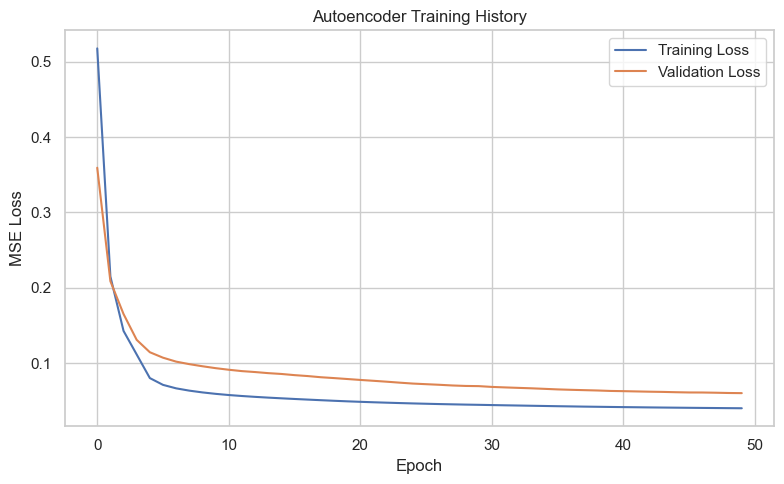

Figure saved to: c:\Code\dissertation_outputs\figures\autoencoder_training_loss_train_only.png


In [30]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Autoencoder Training History")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()

fig_path = base_path / "figures" / "autoencoder_training_loss_train_only.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print(f"Figure saved to: {fig_path}")


#### 10.2 AAPL Test-Period Anomalies Across All Models


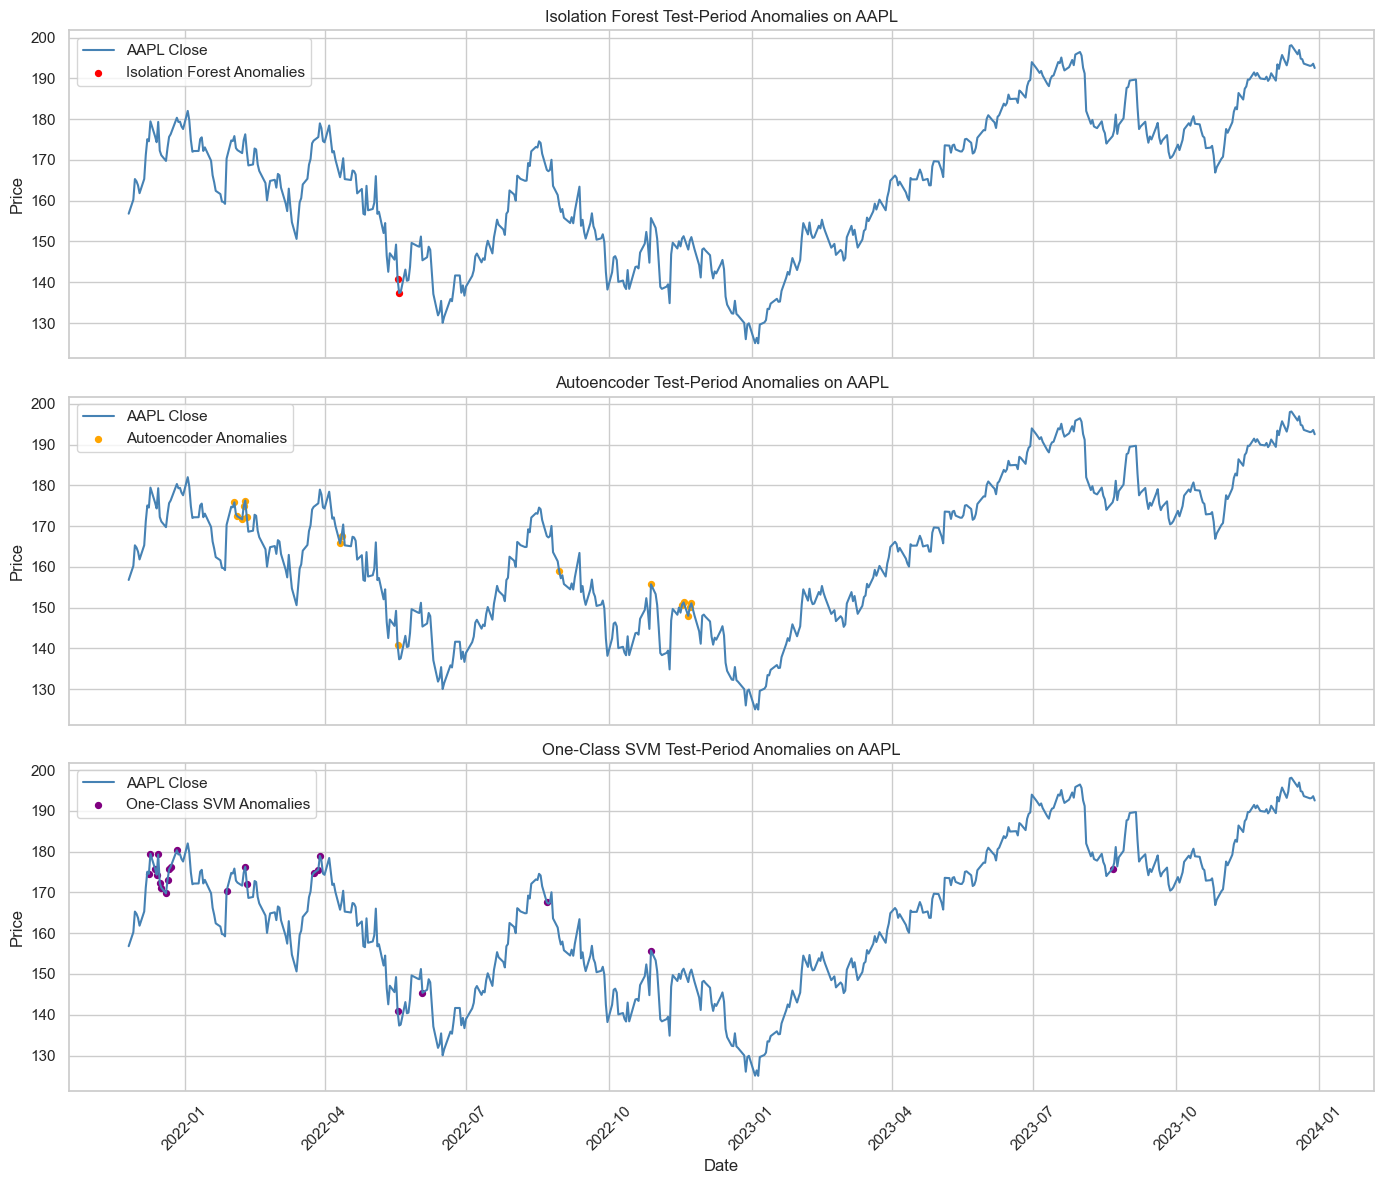

Figure saved to: c:\Code\dissertation_outputs\figures\test_period_anomalies_all_models_aapl.png


In [31]:
plot_df = df[(df["Ticker"] == "AAPL") & (df["Split"] == "Test")].copy()
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
model_plot_specs = [("Anomaly_IF", "Isolation Forest", "red"), ("Anomaly_AE", "Autoencoder", "orange"), ("Anomaly_OCSVM", "One-Class SVM", "purple")]
for ax, (label_col, title, color) in zip(axes, model_plot_specs):
    ax.plot(plot_df["Date"], plot_df["Close"], label="AAPL Close", color="steelblue")
    ax.scatter(plot_df.loc[plot_df[label_col] == 1, "Date"], plot_df.loc[plot_df[label_col] == 1, "Close"], color=color, s=18, label=f"{title} Anomalies")
    ax.set_title(f"{title} Test-Period Anomalies on AAPL")
    ax.set_ylabel("Price")
    ax.legend(loc="upper left")
axes[-1].set_xlabel("Date")
plt.xticks(rotation=45)
plt.tight_layout()

fig_path = base_path / "figures" / "test_period_anomalies_all_models_aapl.png"
plt.savefig(fig_path, dpi=300)
plt.show()
print(f"Figure saved to: {fig_path}")


## 11. Supervised Evaluation on the Controlled Injection Dataset


In [32]:
eval_predictions_df = eval_df.copy()
eval_predictions_df["Pred_IF"] = 0
eval_predictions_df["Pred_AE"] = 0
eval_predictions_df["Pred_OCSVM"] = 0
eval_predictions_df["Eval_IF_Score"] = np.nan
eval_predictions_df["Eval_AE_Error"] = np.nan
eval_predictions_df["Eval_OCSVM_Score"] = np.nan

def predict_if(frame):
    raw_pred = iso_model.predict(frame)
    labels = pd.Series(raw_pred, index=frame.index).replace({1: 0, -1: 1}).astype(int).values
    scores = iso_model.decision_function(frame)
    return labels, scores

def predict_ae(frame):
    scaled = scaler.transform(frame)
    recon = autoencoder.predict(scaled, verbose=0)
    err = np.mean(np.square(scaled - recon), axis=1)
    labels = (err > ae_threshold).astype(int)
    return labels, err

def predict_ocsvm(frame):
    scaled = scaler.transform(frame)
    raw_pred = ocsvm_model.predict(scaled)
    labels = pd.Series(raw_pred, index=frame.index).replace({1: 0, -1: 1}).astype(int).values
    scores = ocsvm_model.decision_function(scaled)
    return labels, scores

for split_name in ["Validation", "Test"]:
    split_mask = eval_predictions_df["Split"] == split_name
    split_frame = eval_predictions_df.loc[split_mask, feature_cols].copy()
    if_labels, if_scores = predict_if(split_frame)
    ae_labels, ae_scores = predict_ae(split_frame)
    ocsvm_labels, ocsvm_scores = predict_ocsvm(split_frame)
    eval_predictions_df.loc[split_mask, "Pred_IF"] = if_labels
    eval_predictions_df.loc[split_mask, "Pred_AE"] = ae_labels
    eval_predictions_df.loc[split_mask, "Pred_OCSVM"] = ocsvm_labels
    eval_predictions_df.loc[split_mask, "Eval_IF_Score"] = if_scores
    eval_predictions_df.loc[split_mask, "Eval_AE_Error"] = ae_scores
    eval_predictions_df.loc[split_mask, "Eval_OCSVM_Score"] = ocsvm_scores

def build_event_detection_rows(model_name, pred_col):
    rows = []
    event_subset = eval_predictions_df[eval_predictions_df["Evaluation_Event_ID"] != ""].copy()
    for event_id, group in event_subset.groupby("Evaluation_Event_ID"):
        group = group.sort_values("Date")
        detection_positions = np.where(group[pred_col].values == 1)[0]
        detected = len(detection_positions) > 0
        rows.append({"Model": model_name, "Event_ID": event_id, "Split": group["Split"].iloc[0], "Ticker": group["Ticker"].iloc[0], "Scenario": group["Evaluation_Scenario"].iloc[0], "Detected": int(detected), "Time_To_Detection": int(detection_positions[0]) if detected else np.nan})
    return pd.DataFrame(rows)

event_detection_df_all = pd.concat([
    build_event_detection_rows("Isolation Forest", "Pred_IF"),
    build_event_detection_rows("Autoencoder", "Pred_AE"),
    build_event_detection_rows("One-Class SVM", "Pred_OCSVM")
], ignore_index=True)

def build_metric_row(model_name, split_name, pred_col):
    subset = eval_predictions_df[eval_predictions_df["Split"].isin(["Validation", "Test"])].copy() if split_name == "HeldOut" else eval_predictions_df[eval_predictions_df["Split"] == split_name].copy()
    y_true = subset["Evaluation_Label"].astype(int).values
    y_pred = subset[pred_col].astype(int).values
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    detection_subset = event_detection_df_all[event_detection_df_all["Split"].isin(["Validation", "Test"])] if split_name == "HeldOut" else event_detection_df_all[event_detection_df_all["Split"] == split_name]
    detection_subset = detection_subset[detection_subset["Model"] == model_name]
    detected_rows = detection_subset[detection_subset["Detected"] == 1]
    return {"Model": model_name, "Split": split_name, "Precision": precision, "Recall": recall, "F1_Score": f1, "Avg_Time_To_Detection": detected_rows["Time_To_Detection"].mean() if not detected_rows.empty else np.nan, "Event_Detection_Rate": detection_subset["Detected"].mean() if not detection_subset.empty else np.nan, "Predicted_Anomalies": int(y_pred.sum()), "True_Anomalies": int(y_true.sum()), "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp)}

metrics_records = []
for model_name in ["Isolation Forest", "Autoencoder", "One-Class SVM"]:
    for split_name in ["Validation", "Test", "HeldOut"]:
        pred_col = {"Isolation Forest": "Pred_IF", "Autoencoder": "Pred_AE", "One-Class SVM": "Pred_OCSVM"}[model_name]
        metrics_records.append(build_metric_row(model_name, split_name, pred_col))

metrics_df = pd.DataFrame(metrics_records)
confusion_df = metrics_df[["Model", "Split", "TN", "FP", "FN", "TP"]].copy()
metrics_df


,Model,Split,Precision,Recall,F1_Score,Avg_Time_To_Detection,Event_Detection_Rate,Predicted_Anomalies,True_Anomalies,TN,FP,FN,TP
0,Isolation Forest,Validation,0.044828,0.144444,0.068421,0.500000,0.266667,290,90,4883,277,77,13
1,Isolation Forest,Test,0.189189,0.388889,0.254545,0.312500,0.533333,185,90,5020,150,55,35
2,Isolation Forest,HeldOut,0.101053,0.266667,0.146565,0.375000,0.400000,475,180,9903,427,132,48
3,Autoencoder,Validation,0.111314,0.677778,0.191223,0.047619,0.700000,548,90,4673,487,29,61
4,Autoencoder,Test,0.090047,0.844444,0.162741,0.000000,0.933333,844,90,4402,768,14,76
5,Autoencoder,HeldOut,0.098420,0.761111,0.174300,0.020408,0.816667,1392,180,9075,1255,43,137
6,One-Class SVM,Validation,0.073171,1.000000,0.136364,0.000000,1.000000,1230,90,4020,1140,0,90
7,One-Class SVM,Test,0.062809,0.988889,0.118115,0.000000,1.000000,1417,90,3842,1328,1,89
8,One-Class SVM,HeldOut,0.067624,0.994444,0.126636,0.000000,1.000000,2647,180,7862,2468,1,179


#### 11.1 Save Evaluation Metrics, Confusion Matrices, Event Detection, and Labeled Data


In [33]:
evaluation_predictions_path = base_path / "results" / "controlled_injection_predictions.csv"
metrics_path = base_path / "results" / "controlled_injection_metrics.csv"
confusion_path = base_path / "results" / "controlled_injection_confusion_matrices.csv"
event_detection_path = base_path / "results" / "controlled_injection_event_detection.csv"

eval_predictions_df.to_csv(evaluation_predictions_path, index=False)
metrics_df.to_csv(metrics_path, index=False)
confusion_df.to_csv(confusion_path, index=False)
event_detection_df_all.to_csv(event_detection_path, index=False)

print(f"Prediction table saved to: {evaluation_predictions_path}")
print(f"Metrics table saved to: {metrics_path}")
print(f"Confusion matrices saved to: {confusion_path}")
print(f"Event detection table saved to: {event_detection_path}")


Prediction table saved to: c:\Code\dissertation_outputs\results\controlled_injection_predictions.csv
Metrics table saved to: c:\Code\dissertation_outputs\results\controlled_injection_metrics.csv
Confusion matrices saved to: c:\Code\dissertation_outputs\results\controlled_injection_confusion_matrices.csv
Event detection table saved to: c:\Code\dissertation_outputs\results\controlled_injection_event_detection.csv


#### 11.2 Unified Baseline Comparison Using Test-Period Results


In [34]:
test_metrics = metrics_df[metrics_df["Split"] == "Test"].set_index("Model")
comparison = pd.DataFrame({
    "Model": ["Isolation Forest", "Autoencoder", "One-Class SVM"],
    "Baseline_Test_Anomalies": [int(df.loc[df["Split"] == "Test", "Anomaly_IF"].sum()), int(df.loc[df["Split"] == "Test", "Anomaly_AE"].sum()), int(df.loc[df["Split"] == "Test", "Anomaly_OCSVM"].sum())],
    "Precision": [test_metrics.loc["Isolation Forest", "Precision"], test_metrics.loc["Autoencoder", "Precision"], test_metrics.loc["One-Class SVM", "Precision"]],
    "Recall": [test_metrics.loc["Isolation Forest", "Recall"], test_metrics.loc["Autoencoder", "Recall"], test_metrics.loc["One-Class SVM", "Recall"]],
    "F1_Score": [test_metrics.loc["Isolation Forest", "F1_Score"], test_metrics.loc["Autoencoder", "F1_Score"], test_metrics.loc["One-Class SVM", "F1_Score"]],
    "Avg_Time_To_Detection": [test_metrics.loc["Isolation Forest", "Avg_Time_To_Detection"], test_metrics.loc["Autoencoder", "Avg_Time_To_Detection"], test_metrics.loc["One-Class SVM", "Avg_Time_To_Detection"]],
    "Event_Detection_Rate": [test_metrics.loc["Isolation Forest", "Event_Detection_Rate"], test_metrics.loc["Autoencoder", "Event_Detection_Rate"], test_metrics.loc["One-Class SVM", "Event_Detection_Rate"]]
})
comparison


,Model,Baseline_Test_Anomalies,Precision,Recall,F1_Score,Avg_Time_To_Detection,Event_Detection_Rate
0,Isolation Forest,158,0.189189,0.388889,0.254545,0.3125,0.533333
1,Autoencoder,775,0.090047,0.844444,0.162741,0.0000,0.933333
2,One-Class SVM,1345,0.062809,0.988889,0.118115,0.0000,1.000000


#### 11.3 Save Unified Comparison Table


In [35]:
comparison_path = base_path / "results" / "baseline_model_comparison_standardized.csv"
comparison.to_csv(comparison_path, index=False)
print(f"Comparison table saved to: {comparison_path}")


Comparison table saved to: c:\Code\dissertation_outputs\results\baseline_model_comparison_standardized.csv


#### 11.4 Overlap Between Baseline Test Predictions


In [36]:
test_df = df[df["Split"] == "Test"].copy()
overlap_df = pd.DataFrame({
    "Comparison": ["IF vs AE", "IF vs OCSVM", "AE vs OCSVM", "Consensus All Three"],
    "Overlap_Count": [int(((test_df["Anomaly_IF"] == 1) & (test_df["Anomaly_AE"] == 1)).sum()), int(((test_df["Anomaly_IF"] == 1) & (test_df["Anomaly_OCSVM"] == 1)).sum()), int(((test_df["Anomaly_AE"] == 1) & (test_df["Anomaly_OCSVM"] == 1)).sum()), int(((test_df["Anomaly_IF"] == 1) & (test_df["Anomaly_AE"] == 1) & (test_df["Anomaly_OCSVM"] == 1)).sum())]
})
overlap_df


,Comparison,Overlap_Count
0,IF vs AE,76
1,IF vs OCSVM,139
2,AE vs OCSVM,628
3,Consensus All Three,74


## 12. Robustness Testing on Held-Out Test Data


In [37]:
perturbation_levels = [0.05, 0.10, 0.15, 0.20, 0.30]
results = []
baseline_test_labels = {"Isolation Forest": df.loc[df["Split"] == "Test", "Anomaly_IF"].astype(int).values, "Autoencoder": df.loc[df["Split"] == "Test", "Anomaly_AE"].astype(int).values, "One-Class SVM": df.loc[df["Split"] == "Test", "Anomaly_OCSVM"].astype(int).values}
baseline_test_scores = {"Isolation Forest": df.loc[df["Split"] == "Test", "IF_score"].values, "Autoencoder": df.loc[df["Split"] == "Test", "AE_error"].values, "One-Class SVM": df.loc[df["Split"] == "Test", "OCSVM_score"].values}


#### 12.1 Run Gaussian Perturbation Tests on the Test Split


In [38]:
for level in perturbation_levels:
    noise = np.random.normal(0, level, X_test.shape)
    X_perturbed = pd.DataFrame(X_test.values + noise, columns=X_test.columns, index=X_test.index)
    if_pred_pert, if_score_pert = predict_if(X_perturbed)
    ae_pred_pert, ae_score_pert = predict_ae(X_perturbed)
    oc_pred_pert, oc_score_pert = predict_ocsvm(X_perturbed)
    model_outputs = {"IF": (baseline_test_labels["Isolation Forest"], if_pred_pert, baseline_test_scores["Isolation Forest"], if_score_pert), "AE": (baseline_test_labels["Autoencoder"], ae_pred_pert, baseline_test_scores["Autoencoder"], ae_score_pert), "OCSVM": (baseline_test_labels["One-Class SVM"], oc_pred_pert, baseline_test_scores["One-Class SVM"], oc_score_pert)}
    result_row = {"Perturbation_Level": level}
    for short_name, (base_labels, pert_labels, base_scores, pert_scores) in model_outputs.items():
        flips = int(np.sum(base_labels != pert_labels))
        jac = jaccard_score(base_labels, pert_labels, zero_division=0)
        ttest_p = ttest_ind(base_scores, pert_scores, equal_var=False).pvalue
        try:
            wilcoxon_p = wilcoxon(base_scores, pert_scores).pvalue
        except Exception:
            wilcoxon_p = np.nan
        result_row[f"{short_name}_Label_Flips"] = flips
        result_row[f"{short_name}_Jaccard"] = jac
        result_row[f"{short_name}_ttest_pvalue"] = ttest_p
        result_row[f"{short_name}_wilcoxon_pvalue"] = wilcoxon_p
    results.append(result_row)


#### 12.2 Robustness Results Table


In [39]:
results_df = pd.DataFrame(results)
results_df["IF_Robustness_Score"] = 1 - (results_df["IF_Label_Flips"] / len(X_test))
results_df["AE_Robustness_Score"] = 1 - (results_df["AE_Label_Flips"] / len(X_test))
results_df["OCSVM_Robustness_Score"] = 1 - (results_df["OCSVM_Label_Flips"] / len(X_test))
results_df


,Perturbation_Level,IF_Label_Flips,IF_Jaccard,IF_ttest_pvalue,IF_wilcoxon_pvalue,AE_Label_Flips,AE_Jaccard,AE_ttest_pvalue,AE_wilcoxon_pvalue,OCSVM_Label_Flips,OCSVM_Jaccard,OCSVM_ttest_pvalue,OCSVM_wilcoxon_pvalue,IF_Robustness_Score,AE_Robustness_Score,OCSVM_Robustness_Score
0,0.05,516,0.212214,0.0,0.0,4402,0.149701,0.0,0.0,3853,0.258468,0.0,0.0,0.901901,0.163118,0.267490
1,0.10,1309,0.091603,0.0,0.0,4481,0.147451,0.0,0.0,3911,0.255898,0.0,0.0,0.751141,0.148099,0.256464
2,0.15,2012,0.064621,0.0,0.0,4485,0.147338,0.0,0.0,3915,0.255703,0.0,0.0,0.617490,0.147338,0.255703
3,0.20,2521,0.054743,0.0,0.0,4485,0.147338,0.0,0.0,3915,0.255703,0.0,0.0,0.520722,0.147338,0.255703
4,0.30,3049,0.045995,0.0,0.0,4485,0.147338,0.0,0.0,3915,0.255703,0.0,0.0,0.420342,0.147338,0.255703


#### 12.3 Save Robustness Results


In [40]:
robustness_path = base_path / "results" / "perturbation_robustness_results_standardized.csv"
results_df.to_csv(robustness_path, index=False)
print(f"Robustness results saved to: {robustness_path}")


Robustness results saved to: c:\Code\dissertation_outputs\results\perturbation_robustness_results_standardized.csv


#### 12.4 Plot Label Flips vs Perturbation


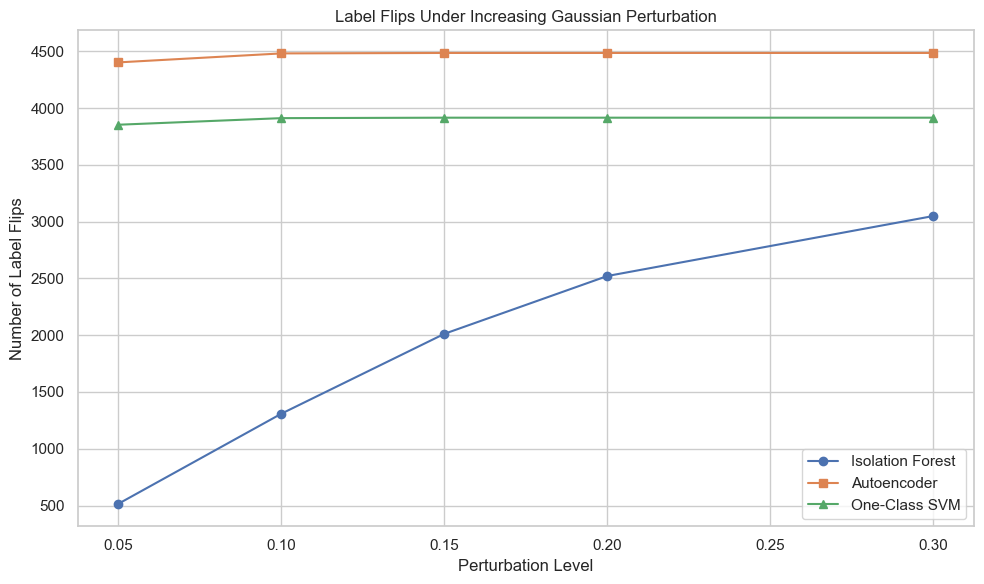

Figure saved to: c:\Code\dissertation_outputs\figures\label_flips_vs_gaussian_perturbation_standardized.png


In [41]:
plt.figure(figsize=(10, 6))
plt.plot(results_df["Perturbation_Level"], results_df["IF_Label_Flips"], marker="o", label="Isolation Forest")
plt.plot(results_df["Perturbation_Level"], results_df["AE_Label_Flips"], marker="s", label="Autoencoder")
plt.plot(results_df["Perturbation_Level"], results_df["OCSVM_Label_Flips"], marker="^", label="One-Class SVM")
plt.title("Label Flips Under Increasing Gaussian Perturbation")
plt.xlabel("Perturbation Level")
plt.ylabel("Number of Label Flips")
plt.legend()
plt.tight_layout()
fig_path = base_path / "figures" / "label_flips_vs_gaussian_perturbation_standardized.png"
plt.savefig(fig_path, dpi=300)
plt.show()
print(f"Figure saved to: {fig_path}")


#### 12.5 Plot Jaccard Similarity vs Perturbation


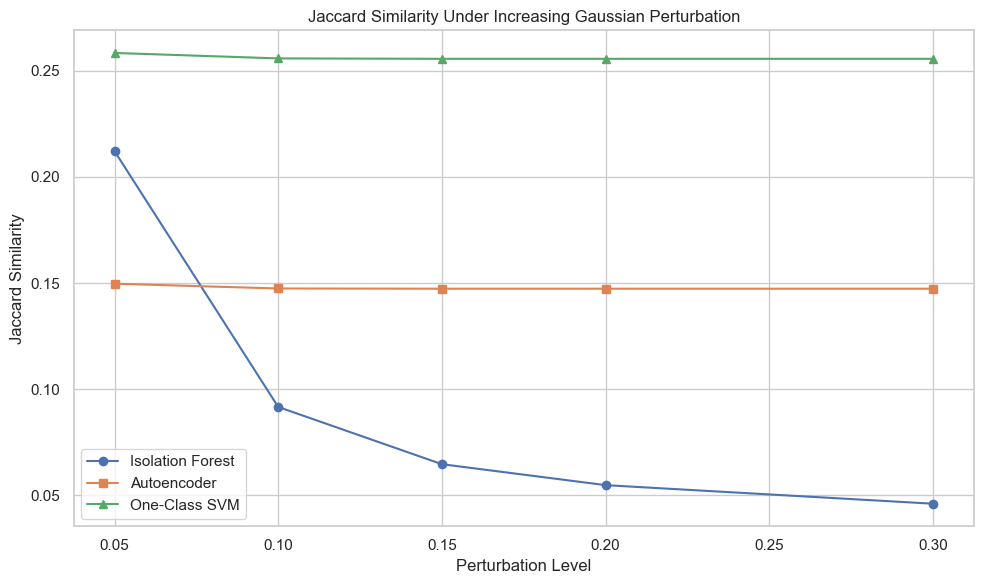

Figure saved to: c:\Code\dissertation_outputs\figures\jaccard_vs_gaussian_perturbation_standardized.png


In [42]:
plt.figure(figsize=(10, 6))
plt.plot(results_df["Perturbation_Level"], results_df["IF_Jaccard"], marker="o", label="Isolation Forest")
plt.plot(results_df["Perturbation_Level"], results_df["AE_Jaccard"], marker="s", label="Autoencoder")
plt.plot(results_df["Perturbation_Level"], results_df["OCSVM_Jaccard"], marker="^", label="One-Class SVM")
plt.title("Jaccard Similarity Under Increasing Gaussian Perturbation")
plt.xlabel("Perturbation Level")
plt.ylabel("Jaccard Similarity")
plt.legend()
plt.tight_layout()
fig_path = base_path / "figures" / "jaccard_vs_gaussian_perturbation_standardized.png"
plt.savefig(fig_path, dpi=300)
plt.show()
print(f"Figure saved to: {fig_path}")


## 13. Financial Stress Scenario Evaluation


#### 13.1 Define Test-Split Stress Scenarios with Consistent Feature Names


In [43]:
X_test_scenarios = {}
price_spike = X_test.copy()
price_spike["Momentum_10"] = price_spike["Momentum_10"] * 1.5
price_spike["MA_Ratio_10"] = price_spike["MA_Ratio_10"] * 1.08
price_spike["MA_Ratio_20"] = price_spike["MA_Ratio_20"] * 1.10
price_spike["Return_Zscore_20"] = price_spike["Return_Zscore_20"] + 2.0
X_test_scenarios["Price Spike"] = price_spike

volume_shock = X_test.copy()
volume_shock["Volume_Change"] = volume_shock["Volume_Change"].fillna(0) + 2.0
volume_shock["Volatility_10"] = volume_shock["Volatility_10"] * 1.3
volume_shock["BB_Width"] = volume_shock["BB_Width"] * 1.5
X_test_scenarios["Volume Shock"] = volume_shock

volatility_shock = X_test.copy()
volatility_shock["Volatility_10"] = volatility_shock["Volatility_10"] * 1.8
volatility_shock["Volatility_20"] = volatility_shock["Volatility_20"] * 1.8
volatility_shock["Drawdown"] = volatility_shock["Drawdown"] - 0.10
volatility_shock["Rolling_Kurt_20"] = volatility_shock["Rolling_Kurt_20"] + 1.0
volatility_shock["BB_Width"] = volatility_shock["BB_Width"] * 1.6
X_test_scenarios["Volatility Shock"] = volatility_shock
list(X_test_scenarios.keys())


['Price Spike', 'Volume Shock', 'Volatility Shock']

#### 13.2 Evaluate Stress Scenario Robustness


In [44]:
def evaluate_scenario(model_name, baseline_labels, pred_labels):
    flips = int(np.sum(baseline_labels != pred_labels))
    jac = jaccard_score(baseline_labels, pred_labels, zero_division=0)
    robustness = 1 - (flips / len(baseline_labels))
    return {"Model": model_name, "Label_Flips": flips, "Jaccard": jac, "Robustness": robustness}

stress_results = []
for scenario_name, scenario_frame in X_test_scenarios.items():
    if_pred, _ = predict_if(scenario_frame)
    ae_pred, _ = predict_ae(scenario_frame)
    oc_pred, _ = predict_ocsvm(scenario_frame)
    stress_results.append({"Scenario": scenario_name, **evaluate_scenario("Isolation Forest", baseline_test_labels["Isolation Forest"], if_pred)})
    stress_results.append({"Scenario": scenario_name, **evaluate_scenario("Autoencoder", baseline_test_labels["Autoencoder"], ae_pred)})
    stress_results.append({"Scenario": scenario_name, **evaluate_scenario("One-Class SVM", baseline_test_labels["One-Class SVM"], oc_pred)})

stress_results_df = pd.DataFrame(stress_results)
stress_results_df


,Scenario,Model,Label_Flips,Jaccard,Robustness
0,Price Spike,Isolation Forest,431,0.214936,0.918061
1,Price Spike,Autoencoder,4476,0.146941,0.149049
2,Price Spike,One-Class SVM,3839,0.259309,0.270152
3,Volume Shock,Isolation Forest,616,0.204134,0.882890
4,Volume Shock,Autoencoder,670,0.510234,0.872624
5,Volume Shock,One-Class SVM,2447,0.354524,0.534791
6,Volatility Shock,Isolation Forest,511,0.236173,0.902852
7,Volatility Shock,Autoencoder,628,0.512044,0.880608
8,Volatility Shock,One-Class SVM,1111,0.519879,0.788783


#### 13.3 Save Stress Results


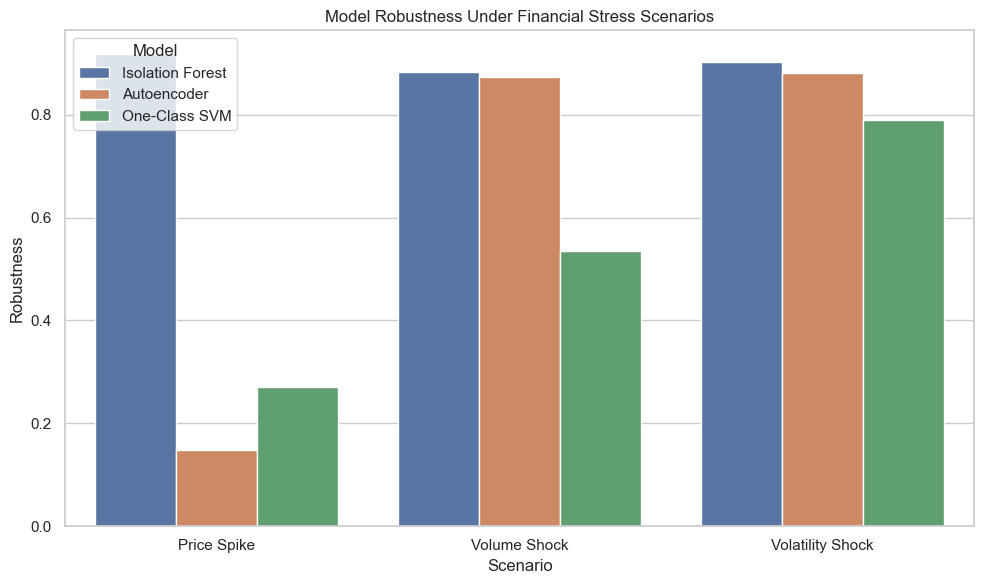

Stress scenario results saved to: c:\Code\dissertation_outputs\results\financial_stress_scenarios_results_standardized.csv
Figure saved to: c:\Code\dissertation_outputs\figures\financial_stress_robustness_comparison_standardized.png


In [45]:
stress_results_path = base_path / "results" / "financial_stress_scenarios_results_standardized.csv"
stress_results_df.to_csv(stress_results_path, index=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=stress_results_df, x="Scenario", y="Robustness", hue="Model")
plt.title("Model Robustness Under Financial Stress Scenarios")
plt.tight_layout()
fig_path = base_path / "figures" / "financial_stress_robustness_comparison_standardized.png"
plt.savefig(fig_path, dpi=300)
plt.show()
print(f"Stress scenario results saved to: {stress_results_path}")
print(f"Figure saved to: {fig_path}")


## 14. SHAP Explainability for Isolation Forest


#### 14.1 Compute SHAP Values on a Held-Out Test Sample


In [46]:
X_shap = X_test.sample(min(500, len(X_test)), random_state=42)
explainer = shap.Explainer(iso_model, X_shap)
shap_values = explainer(X_shap)


#### 14.2 SHAP Summary Plot


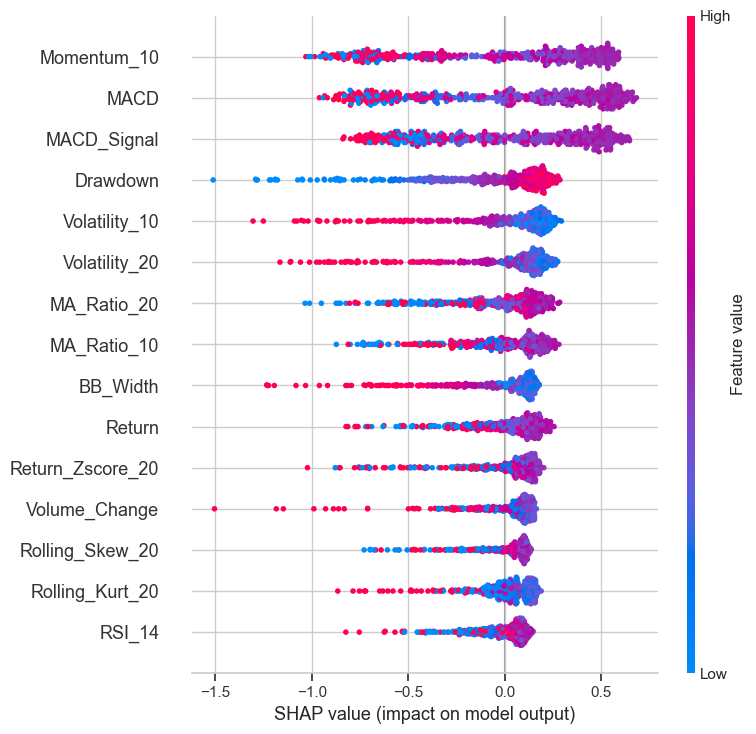

Figure saved to: c:\Code\dissertation_outputs\figures\shap_summary_plot_test_sample.png


In [47]:
shap.summary_plot(shap_values, X_shap, show=False)
plt.tight_layout()
fig_path = base_path / "figures" / "shap_summary_plot_test_sample.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Figure saved to: {fig_path}")


#### 14.3 Mean Absolute SHAP Importance


In [48]:
shap_importance = pd.DataFrame({"Feature": X_shap.columns, "Mean_Abs_SHAP": np.abs(shap_values.values).mean(axis=0)}).sort_values(by="Mean_Abs_SHAP", ascending=False)
shap_path = base_path / "results" / "shap_feature_importance_test_sample.csv"
shap_importance.to_csv(shap_path, index=False)
print(f"SHAP importance saved to: {shap_path}")
shap_importance


SHAP importance saved to: c:\Code\dissertation_outputs\results\shap_feature_importance_test_sample.csv


,Feature,Mean_Abs_SHAP
3,Momentum_10,0.431198
12,MACD,0.422077
13,MACD_Signal,0.383061
10,Drawdown,0.230588
1,Volatility_10,0.201436
2,Volatility_20,0.199412
5,MA_Ratio_20,0.190886
4,MA_Ratio_10,0.180065
14,BB_Width,0.166771
0,Return,0.150976


#### 14.4 SHAP Bar Plot


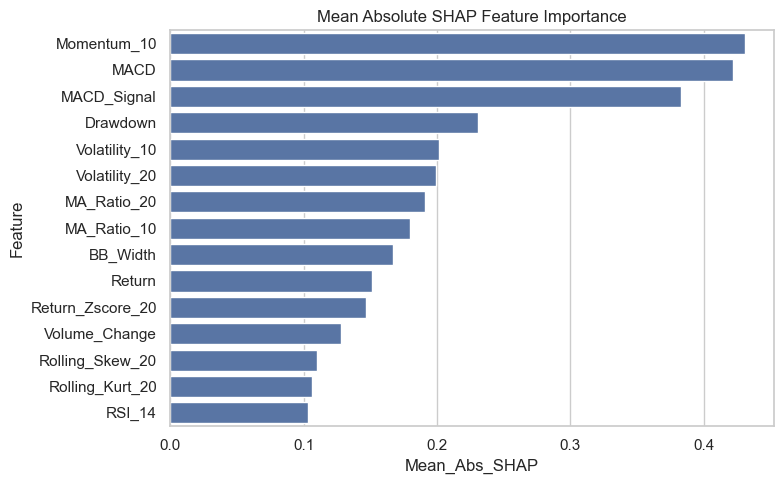

Figure saved to: c:\Code\dissertation_outputs\figures\shap_feature_importance_bar_test_sample.png


In [49]:
plt.figure(figsize=(8, 5))
sns.barplot(data=shap_importance, x="Mean_Abs_SHAP", y="Feature")
plt.title("Mean Absolute SHAP Feature Importance")
plt.tight_layout()
fig_path = base_path / "figures" / "shap_feature_importance_bar_test_sample.png"
plt.savefig(fig_path, dpi=300)
plt.show()
print(f"Figure saved to: {fig_path}")


## 15. Explanation Stability Under Perturbation


In [50]:
top_k = 5
base_importance = pd.Series(np.abs(shap_values.values).mean(axis=0), index=X_shap.columns)


#### 15.1 Evaluate SHAP Stability Across All Gaussian Perturbation Levels


In [51]:
shap_stability_results = []
for level in perturbation_levels:
    noise = np.random.normal(0, level, X_shap.shape)
    X_perturbed_level = pd.DataFrame(X_shap.values + noise, columns=X_shap.columns, index=X_shap.index)
    shap_values_level = explainer(X_perturbed_level)
    pert_importance = pd.Series(np.abs(shap_values_level.values).mean(axis=0), index=X_shap.columns)
    orig_rank = base_importance.rank(ascending=False)
    pert_rank = pert_importance.rank(ascending=False)
    rho, pval = spearmanr(orig_rank, pert_rank)
    orig_top = set(base_importance.sort_values(ascending=False).head(top_k).index)
    pert_top = set(pert_importance.sort_values(ascending=False).head(top_k).index)
    overlap_ratio = len(orig_top.intersection(pert_top)) / top_k
    shap_stability_results.append({"Perturbation_Level": level, "Spearman_Rho": rho, "Spearman_pvalue": pval, f"Top_{top_k}_Overlap": overlap_ratio})

shap_stability_df = pd.DataFrame(shap_stability_results)
shap_stability_path = base_path / "results" / "shap_stability_all_levels_standardized.csv"
shap_stability_df.to_csv(shap_stability_path, index=False)
print(f"SHAP stability results saved to: {shap_stability_path}")
shap_stability_df


SHAP stability results saved to: c:\Code\dissertation_outputs\results\shap_stability_all_levels_standardized.csv


,Perturbation_Level,Spearman_Rho,Spearman_pvalue,Top_5_Overlap
0,0.05,0.707143,0.003195,0.6
1,0.10,0.567857,0.027228,0.2
2,0.15,0.478571,0.071131,0.2
3,0.20,0.503571,0.055655,0.2
4,0.30,0.453571,0.089486,0.0


#### 15.2 Plot SHAP Stability


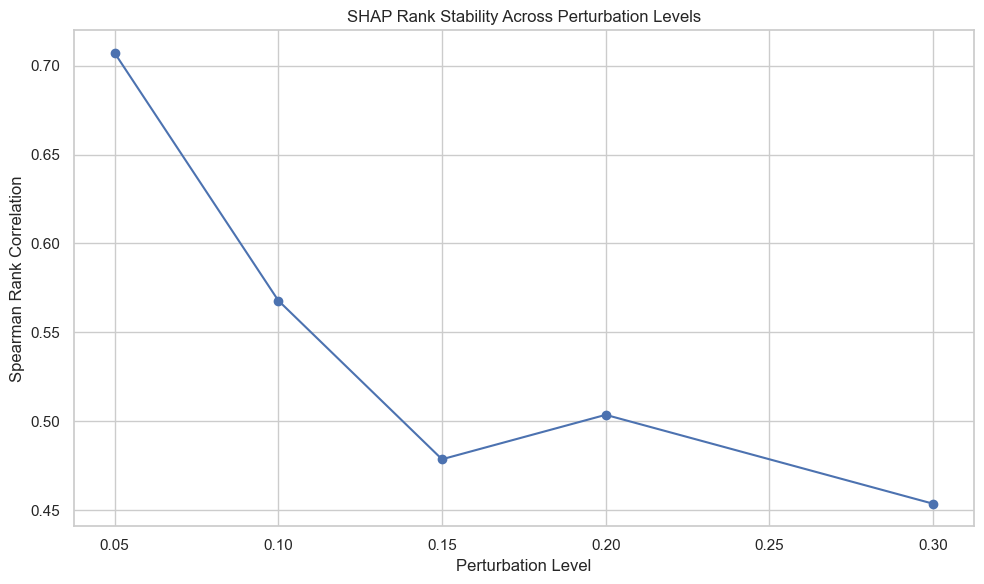

Figure saved to: c:\Code\dissertation_outputs\figures\shap_stability_vs_perturbation_standardized.png


In [52]:
plt.figure(figsize=(10, 6))
plt.plot(shap_stability_df["Perturbation_Level"], shap_stability_df["Spearman_Rho"], marker="o")
plt.title("SHAP Rank Stability Across Perturbation Levels")
plt.xlabel("Perturbation Level")
plt.ylabel("Spearman Rank Correlation")
plt.tight_layout()
fig_path = base_path / "figures" / "shap_stability_vs_perturbation_standardized.png"
plt.savefig(fig_path, dpi=300)
plt.show()
print(f"Figure saved to: {fig_path}")


#### 15.3 Example Explanation Shift at 10 Percent Perturbation


In [53]:
example_level = 0.10
example_noise = np.random.normal(0, example_level, X_shap.shape)
X_perturbed = pd.DataFrame(X_shap.values + example_noise, columns=X_shap.columns, index=X_shap.index)
shap_values_pert = explainer(X_perturbed)


#### 15.4 Rank Comparison


In [54]:
orig_rank = base_importance.rank(ascending=False)
pert_importance = pd.Series(np.abs(shap_values_pert.values).mean(axis=0), index=X_shap.columns)
pert_rank = pert_importance.rank(ascending=False)
rho, pval = spearmanr(orig_rank, pert_rank)
print("Spearman Rank Correlation:", rho)
print("p-value:", pval)


Spearman Rank Correlation: 0.5892857142857142
p-value: 0.02079435848316164


#### 15.5 Top-k Overlap and Save Single-Level Explainability Stability


In [55]:
orig_top = set(base_importance.sort_values(ascending=False).head(top_k).index)
pert_top = set(pert_importance.sort_values(ascending=False).head(top_k).index)
overlap_ratio = len(orig_top.intersection(pert_top)) / top_k
explain_stability = pd.DataFrame({"Metric": ["Spearman_Rank_Correlation", f"Top_{top_k}_Feature_Overlap"], "Value": [rho, overlap_ratio]})
exp_path = base_path / "results" / "explainability_stability_single_level.csv"
explain_stability.to_csv(exp_path, index=False)
print(f"Top-{top_k} feature overlap: {overlap_ratio:.3f}")
print(f"Explainability stability results saved to: {exp_path}")
explain_stability


Top-5 feature overlap: 0.200
Explainability stability results saved to: c:\Code\dissertation_outputs\results\explainability_stability_single_level.csv


,Metric,Value
0,Spearman_Rank_Correlation,0.589286
1,Top_5_Feature_Overlap,0.200000


## 16. Final Summary Tables


In [56]:
avg_robustness = {"Isolation Forest": results_df["IF_Robustness_Score"].mean(), "Autoencoder": results_df["AE_Robustness_Score"].mean(), "One-Class SVM": results_df["OCSVM_Robustness_Score"].mean()}
worst_stress = stress_results_df.groupby("Model")["Robustness"].min().to_dict()
final_summary = comparison.copy()
final_summary["Avg_Gaussian_Robustness"] = final_summary["Model"].map(avg_robustness)
final_summary["Worst_Stress_Robustness"] = final_summary["Model"].map(worst_stress)
final_summary


,Model,Baseline_Test_Anomalies,Precision,Recall,F1_Score,Avg_Time_To_Detection,Event_Detection_Rate,Avg_Gaussian_Robustness,Worst_Stress_Robustness
0,Isolation Forest,158,0.189189,0.388889,0.254545,0.3125,0.533333,0.642319,0.882890
1,Autoencoder,775,0.090047,0.844444,0.162741,0.0000,0.933333,0.150646,0.149049
2,One-Class SVM,1345,0.062809,0.988889,0.118115,0.0000,1.000000,0.258213,0.270152


#### 16.1 Save Final Summary


In [57]:
summary_path = base_path / "results" / "final_model_summary_standardized.csv"
final_summary.to_csv(summary_path, index=False)
print(f"Final summary saved to: {summary_path}")


Final summary saved to: c:\Code\dissertation_outputs\results\final_model_summary_standardized.csv


#### 16.2 Model Failure Analysis


In [58]:
gaussian_30 = results_df.set_index("Perturbation_Level")
failure_analysis = pd.DataFrame({
    "Model": ["Isolation Forest", "Autoencoder", "One-Class SVM"],
    "Baseline_Test_Anomalies": [int(df.loc[df["Split"] == "Test", "Anomaly_IF"].sum()), int(df.loc[df["Split"] == "Test", "Anomaly_AE"].sum()), int(df.loc[df["Split"] == "Test", "Anomaly_OCSVM"].sum())],
    "Gaussian_30pct_Label_Flips": [gaussian_30.loc[0.30, "IF_Label_Flips"], gaussian_30.loc[0.30, "AE_Label_Flips"], gaussian_30.loc[0.30, "OCSVM_Label_Flips"]],
    "Worst_Stress_Robustness": [worst_stress["Isolation Forest"], worst_stress["Autoencoder"], worst_stress["One-Class SVM"]],
    "Interpretation": ["Tree-based detector remains comparatively stable under diffuse perturbation but should still be monitored for drift.", "Reconstruction boundary is sensitive to shifted inputs, which is useful for detection but increases perturbation sensitivity.", "Kernel baseline offers a useful comparator but may degrade when scaled feature geometry changes materially."]
})
failure_analysis


,Model,Baseline_Test_Anomalies,Gaussian_30pct_Label_Flips,Worst_Stress_Robustness,Interpretation
0,Isolation Forest,158,3049,0.882890,Tree-based detector remains comparatively stab...
1,Autoencoder,775,4485,0.149049,Reconstruction boundary is sensitive to shifte...
2,One-Class SVM,1345,3915,0.270152,Kernel baseline offers a useful comparator but...


#### 16.3 Save Failure Analysis


In [59]:
failure_analysis_path = base_path / "results" / "model_failure_analysis_standardized.csv"
failure_analysis.to_csv(failure_analysis_path, index=False)
print(f"Model failure analysis saved to: {failure_analysis_path}")


Model failure analysis saved to: c:\Code\dissertation_outputs\results\model_failure_analysis_standardized.csv


## 17. Dissertation Narrative Mapping


In [60]:
best_f1_model = comparison.sort_values("F1_Score", ascending=False).iloc[0]["Model"]
best_robust_model = final_summary.sort_values("Avg_Gaussian_Robustness", ascending=False).iloc[0]["Model"]
best_detection_model = comparison.sort_values("Event_Detection_Rate", ascending=False).iloc[0]["Model"]
narrative_lines = [
    "# Dissertation Alignment Summary",
    "",
    "## Aim Alignment",
    "The notebook now evaluates anomaly detection, robustness, and explainability within one reproducible time-series pipeline.",
    "",
    "## Research Question Coverage",
    "- Controlled event injection enables Precision, Recall, F1-Score, and Time-to-Detection on held-out data.",
    f"- {best_detection_model} achieved the highest event detection rate on the controlled test set.",
    f"- {best_f1_model} achieved the strongest F1-Score on the controlled test set.",
    f"- {best_robust_model} delivered the strongest average Gaussian robustness across held-out perturbation levels.",
    "",
    "## Explainability Scope",
    "- SHAP is explicitly scoped to Isolation Forest as the primary interpretable model for dissertation analysis.",
    "- Explanation stability is quantified through Spearman rank correlation and top-k feature overlap under perturbation.",
    "",
    "## Methodological Improvements",
    "- Models are trained only on the chronological training split.",
    "- Validation and test splits are reserved for controlled evaluation and robustness assessment.",
    "- Standardized CSV and figure outputs are written to reproducible paths."
]
narrative_text = "`n".join(narrative_lines)
print(narrative_text)


# Dissertation Alignment Summary`n`n## Aim Alignment`nThe notebook now evaluates anomaly detection, robustness, and explainability within one reproducible time-series pipeline.`n`n## Research Question Coverage`n- Controlled event injection enables Precision, Recall, F1-Score, and Time-to-Detection on held-out data.`n- One-Class SVM achieved the highest event detection rate on the controlled test set.`n- Isolation Forest achieved the strongest F1-Score on the controlled test set.`n- Isolation Forest delivered the strongest average Gaussian robustness across held-out perturbation levels.`n`n## Explainability Scope`n- SHAP is explicitly scoped to Isolation Forest as the primary interpretable model for dissertation analysis.`n- Explanation stability is quantified through Spearman rank correlation and top-k feature overlap under perturbation.`n`n## Methodological Improvements`n- Models are trained only on the chronological training split.`n- Validation and test splits are reserved for contr

#### 17.1 Save Narrative Summary


In [61]:
narrative_path = base_path / "results" / "dissertation_alignment_summary.md"
with open(narrative_path, "w", encoding="utf-8") as f:
    f.write(narrative_text)
print(f"Narrative summary saved to: {narrative_path}")


Narrative summary saved to: c:\Code\dissertation_outputs\results\dissertation_alignment_summary.md


## 18. Validation Checks


In [62]:
assert set(["Train", "Validation", "Test"]) == set(df["Split"].unique())
assert eval_df["Evaluation_Label"].sum() > 0
assert all(col in X_test_scenarios["Volume Shock"].columns for col in feature_cols)
assert metrics_df["Model"].nunique() == 3
assert results_df.shape[0] == len(perturbation_levels)
train_max = df.loc[df["Split"] == "Train", "Date"].max()
val_min = df.loc[df["Split"] == "Validation", "Date"].min()
val_max = df.loc[df["Split"] == "Validation", "Date"].max()
test_min = df.loc[df["Split"] == "Test", "Date"].min()
print("Validation checks passed.")
print(f"Train ends on: {train_max.date()}")
print(f"Validation starts on: {val_min.date()} and ends on: {val_max.date()}")
print(f"Test starts on: {test_min.date()}")
print(f"Injected anomaly rows: {int(eval_df['Evaluation_Label'].sum())}")


Validation checks passed.
Train ends on: 2019-10-25
Validation starts on: 2019-10-28 and ends on: 2021-11-24
Test starts on: 2021-11-26
Injected anomaly rows: 180


#### 18.1 Notebook Output Snapshot


In [63]:
display(metrics_df.head())
display(final_summary)
display(failure_analysis)


,Model,Split,Precision,Recall,F1_Score,Avg_Time_To_Detection,Event_Detection_Rate,Predicted_Anomalies,True_Anomalies,TN,FP,FN,TP
0,Isolation Forest,Validation,0.044828,0.144444,0.068421,0.500000,0.266667,290,90,4883,277,77,13
1,Isolation Forest,Test,0.189189,0.388889,0.254545,0.312500,0.533333,185,90,5020,150,55,35
2,Isolation Forest,HeldOut,0.101053,0.266667,0.146565,0.375000,0.400000,475,180,9903,427,132,48
3,Autoencoder,Validation,0.111314,0.677778,0.191223,0.047619,0.700000,548,90,4673,487,29,61
4,Autoencoder,Test,0.090047,0.844444,0.162741,0.000000,0.933333,844,90,4402,768,14,76


,Model,Baseline_Test_Anomalies,Precision,Recall,F1_Score,Avg_Time_To_Detection,Event_Detection_Rate,Avg_Gaussian_Robustness,Worst_Stress_Robustness
0,Isolation Forest,158,0.189189,0.388889,0.254545,0.3125,0.533333,0.642319,0.882890
1,Autoencoder,775,0.090047,0.844444,0.162741,0.0000,0.933333,0.150646,0.149049
2,One-Class SVM,1345,0.062809,0.988889,0.118115,0.0000,1.000000,0.258213,0.270152


,Model,Baseline_Test_Anomalies,Gaussian_30pct_Label_Flips,Worst_Stress_Robustness,Interpretation
0,Isolation Forest,158,3049,0.882890,Tree-based detector remains comparatively stab...
1,Autoencoder,775,4485,0.149049,Reconstruction boundary is sensitive to shifte...
2,One-Class SVM,1345,3915,0.270152,Kernel baseline offers a useful comparator but...


#### 18.2 Key File Paths


In [64]:
key_paths = {"Evaluation dataset": evaluation_dataset_path, "Event log": event_log_path, "Metrics": metrics_path, "Robustness": robustness_path, "Stress results": stress_results_path, "SHAP importance": shap_path, "Final summary": summary_path, "Narrative summary": narrative_path}
for label, path_obj in key_paths.items():
    print(f"{label}: {path_obj}")


Evaluation dataset: c:\Code\dissertation_outputs\data\evaluation_dataset_with_injected_events.csv
Event log: c:\Code\dissertation_outputs\data\synthetic_event_log.csv
Metrics: c:\Code\dissertation_outputs\results\controlled_injection_metrics.csv
Robustness: c:\Code\dissertation_outputs\results\perturbation_robustness_results_standardized.csv
Stress results: c:\Code\dissertation_outputs\results\financial_stress_scenarios_results_standardized.csv
SHAP importance: c:\Code\dissertation_outputs\results\shap_feature_importance_test_sample.csv
Final summary: c:\Code\dissertation_outputs\results\final_model_summary_standardized.csv
Narrative summary: c:\Code\dissertation_outputs\results\dissertation_alignment_summary.md


#### 18.3 Research Question Alignment Table


In [65]:
rq_alignment = pd.DataFrame({
    "Research_Question_Area": ["Cybersecurity and anomaly detection", "Behaviour under abnormal inputs", "Predictive resilience without loss of interpretability", "Explainability stability under perturbation", "Integrated monitoring framework"],
    "Implemented_Evidence": ["Isolation Forest, Autoencoder, and One-Class SVM anomaly pipeline", "Gaussian perturbation tests plus named stress scenarios", "Controlled injection metrics with Precision, Recall, F1, and Time-to-Detection", "SHAP feature importance and stability analysis across perturbation levels", "Unified output tables, failure analysis, and narrative synthesis"],
    "Primary_Output": [str(comparison_path), str(robustness_path), str(metrics_path), str(shap_stability_path), str(summary_path)]
})
rq_alignment_path = base_path / "results" / "research_question_alignment.csv"
rq_alignment.to_csv(rq_alignment_path, index=False)
print(f"Research question alignment saved to: {rq_alignment_path}")
rq_alignment


Research question alignment saved to: c:\Code\dissertation_outputs\results\research_question_alignment.csv


,Research_Question_Area,Implemented_Evidence,Primary_Output
0,Cybersecurity and anomaly detection,"Isolation Forest, Autoencoder, and One-Class S...",c:\Code\dissertation_outputs\results\baseline_...
1,Behaviour under abnormal inputs,Gaussian perturbation tests plus named stress ...,c:\Code\dissertation_outputs\results\perturbat...
2,Predictive resilience without loss of interpre...,"Controlled injection metrics with Precision, R...",c:\Code\dissertation_outputs\results\controlle...
3,Explainability stability under perturbation,SHAP feature importance and stability analysis...,c:\Code\dissertation_outputs\results\shap_stab...
4,Integrated monitoring framework,"Unified output tables, failure analysis, and n...",c:\Code\dissertation_outputs\results\final_mod...


## 19. Framework Extensions and Missing Evidence

This final extension step adds the adaptive thresholding, majority-vote ensemble, supervised early-warning classifier, ROC/confusion visualisations, runtime benchmarking, extended SHAP analysis, multi-asset SHAP stability, stress timeline, and McNemar tests required by the improved framework.


In [66]:
%run scripts/step_19_framework_extensions.py



Step 19: Framework Extensions and Missing Evidence



100%|██████████| 35/35 [00:02<00:00, 17.03it/s]


Adaptive thresholds:
           Model  Threshold  Precision   Recall       F1
Isolation Forest  -0.056050   0.085165 0.688889 0.151589
     Autoencoder   0.459772   0.159292 0.600000 0.251748
   One-Class SVM   1.041262   0.176072 0.866667 0.292683

Framework metrics:
                    Model      Split  Precision   Recall  F1_Score  ROC_AUC
Isolation Forest Adaptive Validation   0.085165 0.688889  0.151589 0.886652
     Autoencoder Adaptive Validation   0.159292 0.600000  0.251748 0.886863
   One-Class SVM Adaptive Validation   0.176072 0.866667  0.292683 0.942573
   Ensemble Majority Vote Validation   0.177419 0.855556  0.293893 0.935170
Isolation Forest Adaptive       Test   0.091281 0.744444  0.162621 0.909211
     Autoencoder Adaptive       Test   0.142566 0.777778  0.240964 0.923580
   One-Class SVM Adaptive       Test   0.207182 0.833333  0.331858 0.968167
   Ensemble Majority Vote       Test   0.208122 0.911111  0.338843 0.966877
 Supervised Early Warning       Test   0.571429

## 20. Chapter 4 Visual Storytelling Layer

This final visual layer creates granular comparative figures and summary tables that make the Chapter 4 evidence easier to explain: pipeline diagram, metric heatmaps, precision-recall trade-off, ensemble lift, runtime-vs-F1, robustness/stress heatmaps, SHAP comparison heatmaps, supervised model panel, and an evidence dashboard.


In [67]:
%run scripts/step_20_chapter4_visual_story.py



Step 20: Chapter 4 Visual Storytelling Layer

Figure saved: c:\Code\dissertation_outputs\figures\chapter4_visuals\01_framework_pipeline_diagram.png
Figure saved: c:\Code\dissertation_outputs\figures\chapter4_visuals\02_model_performance_metric_heatmap.png
Figure saved: c:\Code\dissertation_outputs\figures\chapter4_visuals\03_precision_recall_tradeoff_bubble.png
Figure saved: c:\Code\dissertation_outputs\figures\chapter4_visuals\04_ensemble_lift_vs_isolation_forest.png
Figure saved: c:\Code\dissertation_outputs\figures\chapter4_visuals\05_detection_outcome_breakdown.png
Figure saved: c:\Code\dissertation_outputs\figures\chapter4_visuals\06_runtime_vs_f1_tradeoff.png
Figure saved: c:\Code\dissertation_outputs\figures\chapter4_visuals\07_gaussian_robustness_jaccard_heatmap.png
Figure saved: c:\Code\dissertation_outputs\figures\chapter4_visuals\08_stress_scenario_robustness_heatmap.png
Figure saved: c:\Code\dissertation_outputs\figures\chapter4_visuals\09_cross_model_shap_feature_heatmap.